# Notebook - Find best Drug compound for `Marburg` virus

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [250]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [251]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from copy import deepcopy
import pickle

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [252]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [253]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "Marburg_bestMACAW/")
os.makedirs(saveDir, exist_ok=True)

In [254]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')

### Filter columns and keeping only data for Marburg virus

In [255]:
allVirusData_chEMBL_wMACAW =  allVirusData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
MarburgVirusData_chEMBL = allVirusData_chEMBL_wMACAW[allVirusData_chEMBL_wMACAW['Virus'] == 'Marburg']
MarburgVirusData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
14291,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,38.60,4.413413,Marburg
14292,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,7.96,5.099087,Marburg
14293,CHEMBL5584196,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2ccc(F)cc2)CC1,20.00,NaN,Marburg
14294,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,32.80,4.484126,Marburg
14295,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,3.00,5.522879,Marburg
...,...,...,...,...,...
14489,CHEMBL5595280,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCCCC1)C...,107.00,3.970616,Marburg
14490,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,47.60,4.322393,Marburg
14491,CHEMBL1655,CN(C)CCOc1ccc(/C(=C(/CCCl)c2ccccc2)c2ccccc2)cc1,0.70,6.154902,Marburg
14492,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,4.60,5.337242,Marburg


### Remove `Remdesivir` from training set

In [256]:
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Remdesivir_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
MarburgVirusData_chEMBL["canonical_smiles"] = (
    MarburgVirusData_chEMBL["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Remove rows matching Remdesivir
mask = MarburgVirusData_chEMBL["canonical_smiles"] != remCan
MarburgVirusData_chEMBL_clean = MarburgVirusData_chEMBL[mask].copy()

print("Original shape of data frame:", len(MarburgVirusData_chEMBL))
print("After removing Remdesivir:", len(MarburgVirusData_chEMBL_clean))
MarburgVirusData_chEMBL = MarburgVirusData_chEMBL_clean.copy()

Original shape of data frame: 203
After removing Remdesivir: 203


### Rename columns

In [257]:
MarburgVirusData_chEMBL = MarburgVirusData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Virus" : "VirusClassifier",
})

### Compound Distribution Across Viruses

In [258]:
virus_counts = MarburgVirusData_chEMBL['VirusClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(MarburgVirusData_chEMBL)

print(f"\n{'Virus':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Virus                               Count   Percentage
----------------------------------------------------------------------
Marburg                               203      100.00%
----------------------------------------------------------------------
TOTAL                                 203      100.00%

Number of unique viruses: 1


### Add `ID` column to left

In [259]:
MarburgVirusData_chEMBL.insert(0, 'ID', range(1, len(MarburgVirusData_chEMBL) + 1))
MarburgVirusData_chEMBL.head()

,ID,compound_id,Smiles,value_uM,pPotency,VirusClassifier,canonical_smiles
14291,1,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,38.60,4.413413,Marburg,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1
14292,2,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,7.96,5.099087,Marburg,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1
14293,3,CHEMBL5584196,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2ccc(F)cc2)CC1,20.00,NaN,Marburg,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2ccc(F)cc2)CC1
14294,4,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,32.80,4.484126,Marburg,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1
14295,5,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,3.00,5.522879,Marburg,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `VirusClassifier`

In [260]:
MarburgVirusData_chEMBL = MarburgVirusData_chEMBL.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "VirusClassifier"]
)
MarburgVirusData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
14291,1,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,4.413413,Marburg
14292,2,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,5.099087,Marburg
14293,3,CHEMBL5584196,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2ccc(F)cc2)CC1,NaN,Marburg
14294,4,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,4.484126,Marburg
14295,5,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,5.522879,Marburg


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [261]:
print("Original shape:", MarburgVirusData_chEMBL.shape)

MarburgVirusData_chEMBL = MarburgVirusData_chEMBL[MarburgVirusData_chEMBL['pPotency'].notna() 
    & (MarburgVirusData_chEMBL['pPotency'] > 0) ]   # & (MarburgVirusData_chEMBL['pPotency'] < 12)

print("Shape after cleaning 'pPotency' value:", MarburgVirusData_chEMBL.shape)

Original shape: (203, 5)
Shape after cleaning 'pPotency' value: (186, 5)


In [262]:
MarburgVirusData_chEMBL

,ID,compound_id,Smiles,pPotency,VirusClassifier
14291,1,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,4.413413,Marburg
14292,2,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,5.099087,Marburg
14294,4,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,4.484126,Marburg
14295,5,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,5.522879,Marburg
14296,6,CHEMBL5592994,CCN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3...,4.521434,Marburg
...,...,...,...,...,...
14489,199,CHEMBL5595280,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCCCC1)C...,3.970616,Marburg
14490,200,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,4.322393,Marburg
14491,201,CHEMBL1655,CN(C)CCOc1ccc(/C(=C(/CCCl)c2ccccc2)c2ccccc2)cc1,6.154902,Marburg
14492,202,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,5.337242,Marburg


### Count duplicate SMILES

In [263]:
duplicates = MarburgVirusData_chEMBL.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 34


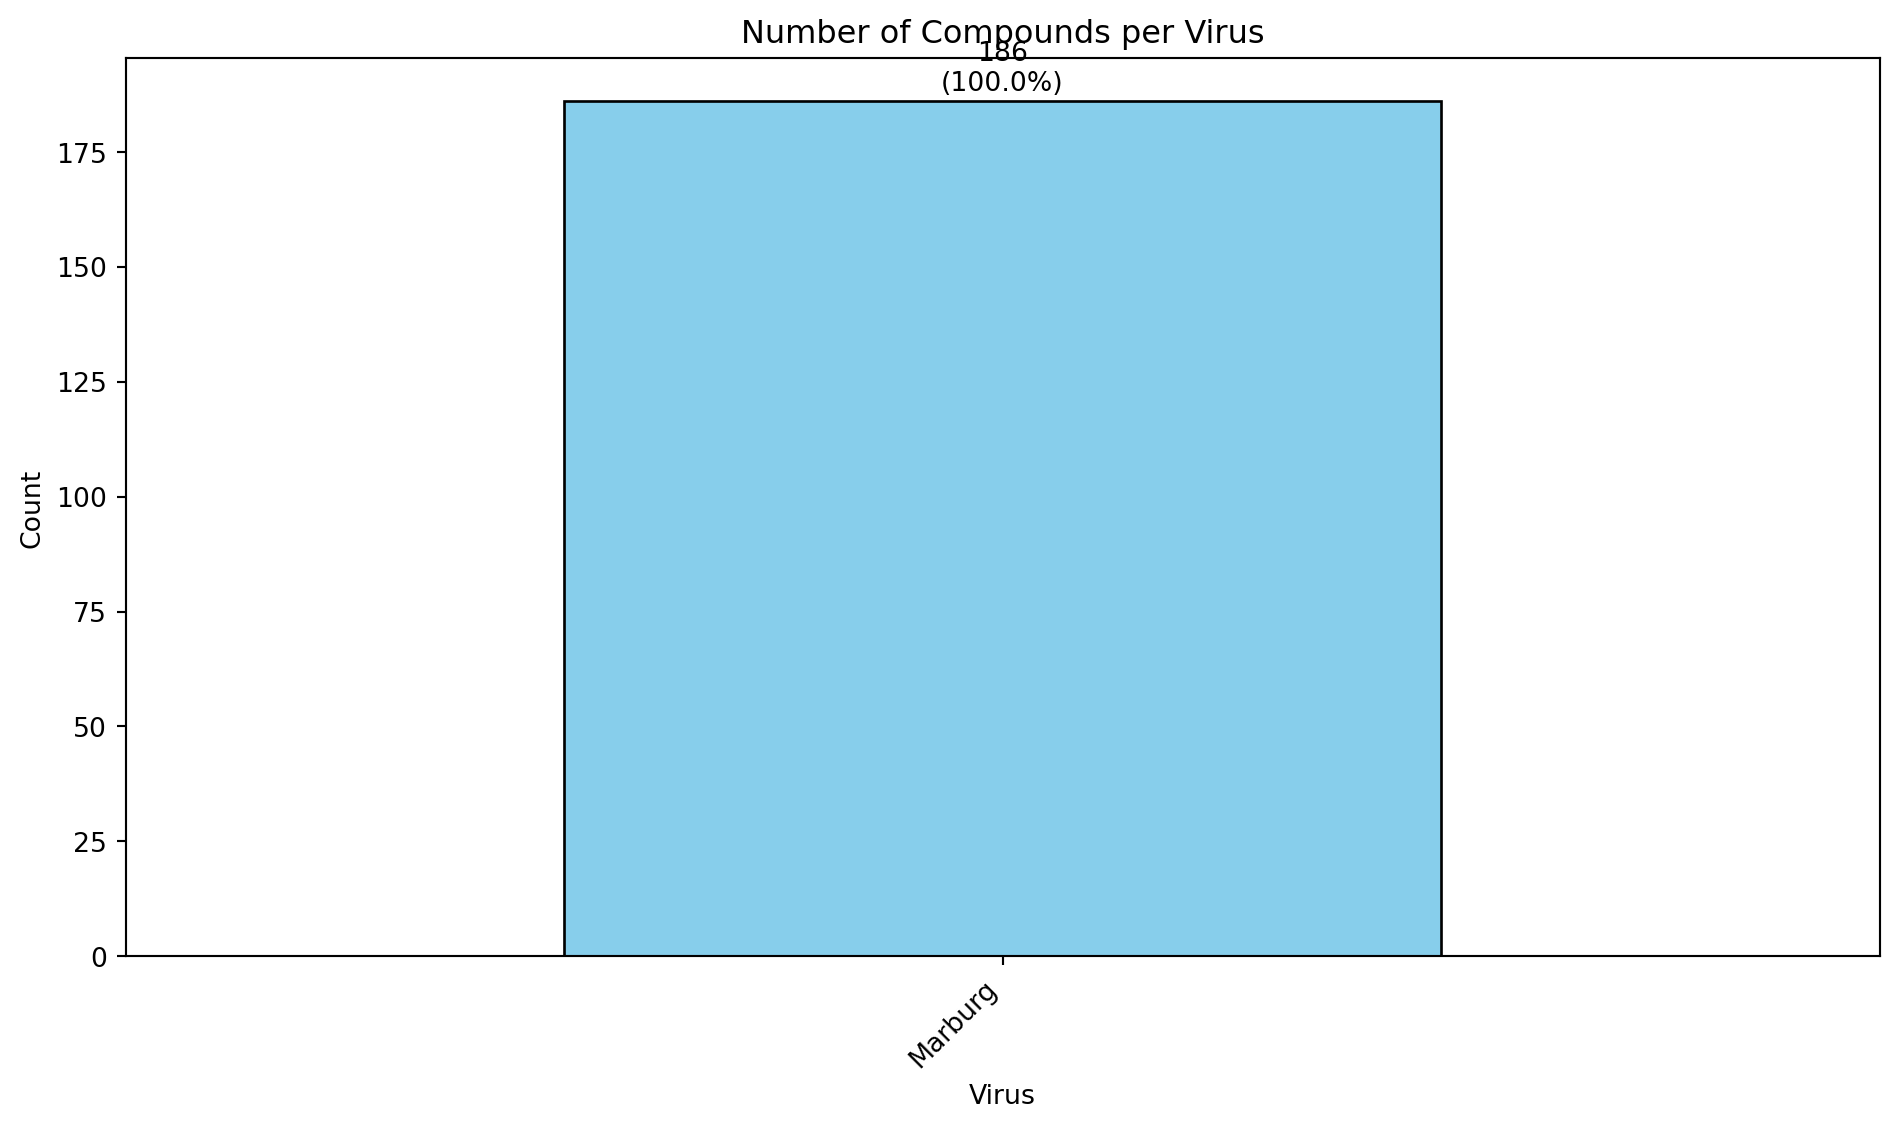

In [264]:
# Get counts and percentages
counts = MarburgVirusData_chEMBL['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [265]:
MarburgVirusData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "MarburgVirusData_chEMBL_MLready.csv"), index=False)

### Create MACAW embeedings to run ART

In [237]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=150, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(MarburgVirusData_chEMBL['Smiles'], MarburgVirusData_chEMBL['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "MarburgVirusData_chEMBL_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(MarburgVirusData_chEMBL['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=MarburgVirusData_chEMBL.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
MarburgVirusData_chEMBL_wMACAW = pd.concat([MarburgVirusData_chEMBL, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {MarburgVirusData_chEMBL.shape}")
print(f"New dataframe shape: {MarburgVirusData_chEMBL_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
MarburgVirusData_chEMBL_wMACAW.head()

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/MarburgVirusData_chEMBL_MACAW_transformer.joblib
MACAW embeddings shape: (186, 45)

Original dataframe shape: (186, 5)
New dataframe shape: (186, 50)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45']


,ID,compound_id,Smiles,pPotency,VirusClassifier,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
14291,1,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,4.413413,Marburg,-0.122310,0.274089,-0.040032,0.139557,-0.005811,...,-0.074232,0.087697,-0.008297,0.050264,-0.007506,0.093003,-0.007375,0.079435,-0.045863,0.002037
14292,2,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,5.099087,Marburg,-0.137225,0.327071,-0.027621,0.186855,0.045965,...,0.098879,-0.004992,0.007890,-0.014787,0.062270,-0.019189,0.089122,0.026018,-0.049004,0.034543
14294,4,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,4.484126,Marburg,-0.119712,0.273791,-0.030392,0.157136,0.033473,...,-0.006600,0.048906,0.082594,0.002345,0.014015,-0.038030,-0.012761,0.048388,0.021040,0.049789
14295,5,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,5.522879,Marburg,0.009413,0.020522,0.035893,-0.354140,0.070985,...,-0.039918,-0.138693,-0.020510,0.156257,0.069440,-0.129893,0.103332,0.066651,0.170467,0.108382
14296,6,CHEMBL5592994,CCN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3...,4.521434,Marburg,0.393294,0.006360,-0.073046,-0.014516,0.021267,...,-0.151761,-0.171347,0.020081,0.063721,0.034510,-0.021248,0.194124,-0.025008,-0.077201,-0.060769


In [238]:
MarburgVirusData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "MarburgVirusData_chEMBL_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [196]:
# df = MarburgVirusData_chEMBL
Y = MarburgVirusData_chEMBL.pPotency
smiles = MarburgVirusData_chEMBL.Smiles

In [197]:
print(len(smiles))

186


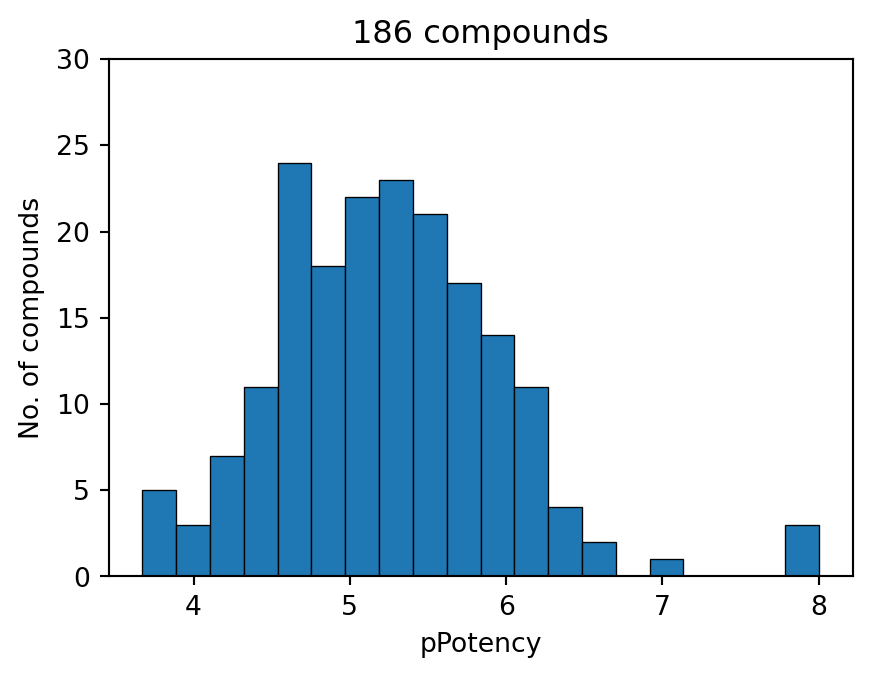

In [198]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [199]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [200]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [210]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=150, 
    random_state=42
)


After cleaning NaN values, reset the indices

In [211]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 186 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [212]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.11
  RMSE: 0.13
  R²:   0.96
Test Set:
  MAE:  0.28
  RMSE: 0.40
  R²:   0.70

Best params (sample): [{'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 30, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}]
CPU times: user 105 ms, sys: 29.3 ms, total: 134 ms
Wall time: 2.07 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburg_bestMACAW//MarburgVirus_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburg_bestMACAW//MarburgVirus_CV_TrTs.png


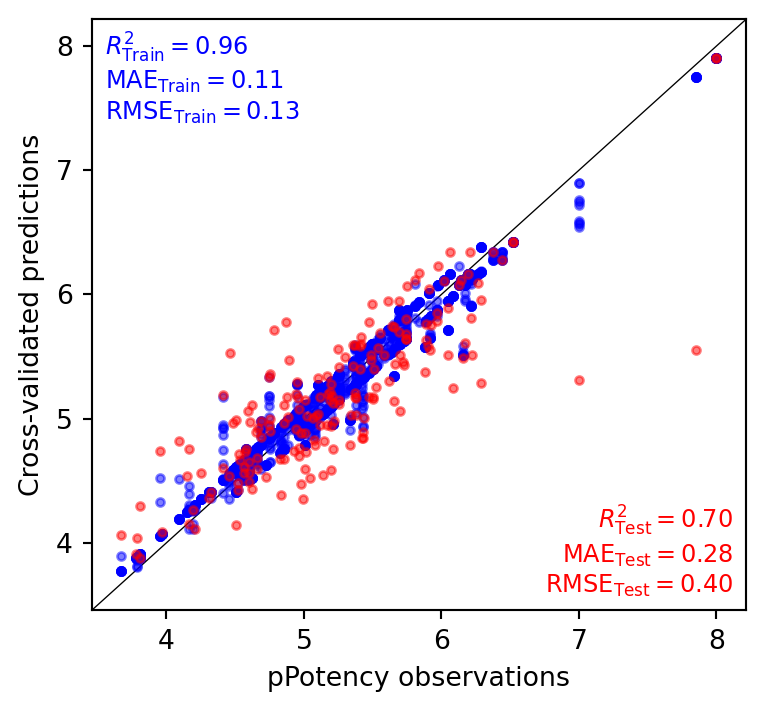

In [213]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/MarburgVirus_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [214]:
mcw.fit(smiles, Y)

In [215]:
X_all = mcw.transform(smiles)
X_all.shape

(186, 45)

Training samples: 148
Test samples: 38
Feature dimensions: 45

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 10
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.31

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.96            0.68            0.28           
MAE        0.11            0.32            0.21           
RMSE       0.14            0.46            0.32           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburg_bestMACAW//MarburgVirus_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sg

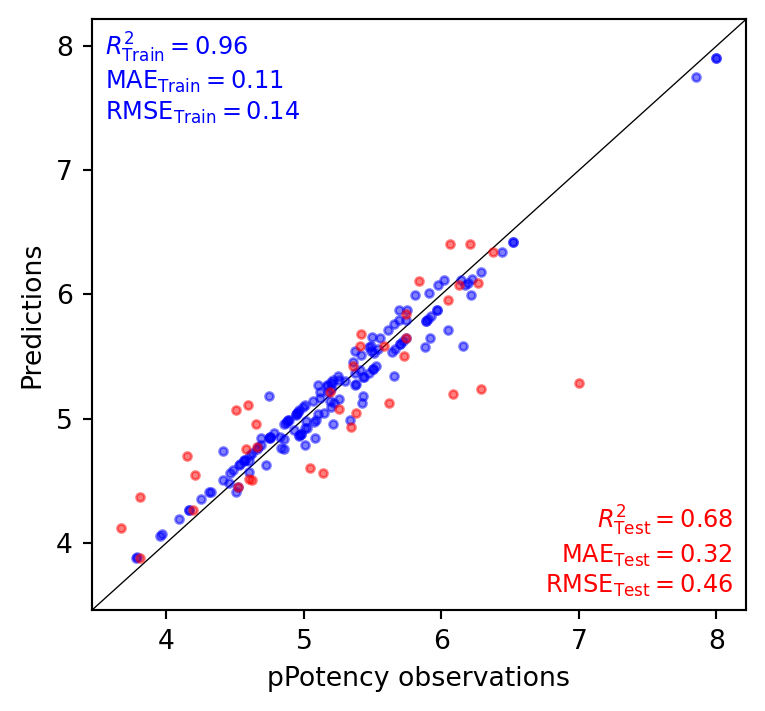

CPU times: user 1.09 s, sys: 62.5 ms, total: 1.16 s
Wall time: 1.78 s


In [218]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=145, 
    random_state=42
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/MarburgVirus_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [239]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = MarburgVirusData_chEMBL_wMACAW.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 152
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.14,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.72,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.70,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.37,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.88,7,https://real.enamine.net/public-enum-files/Z38...


Generate predictions for the H1 receptor:

In [240]:
smi_lib_EnamineDataset_wMACAW = mcw.transform(smi_lib_EnamineDataset)

# Create column names
num_features = smi_lib_EnamineDataset_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_EnamineDataset = pd.DataFrame(smi_lib_EnamineDataset_wMACAW, columns=column_names, index=smi_lib_EnamineDataset.index)
# Then add SMILES as first column
SMILES_lib_EnamineDataset.insert(0, 'SMILES', smi_lib_EnamineDataset)
# Save to CSV
SMILES_lib_EnamineDataset.to_csv(os.path.join(saveDir, "Marburg_EnamineDataset_wMACAW.csv"), index=False)
SMILES_lib_EnamineDataset

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,0.061590,0.025312,-0.031838,-0.164235,0.047803,0.049884,0.031639,-0.023425,-0.015294,...,-0.007161,0.025602,0.032338,0.016198,0.036020,-0.009723,-0.006757,0.011134,0.039658,-0.007406
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,0.011383,0.074644,0.017088,-0.111969,0.053477,-0.014637,0.025688,-0.015291,0.021558,...,-0.004822,0.021165,0.005645,0.008997,-0.034164,-0.001001,-0.014240,-0.001732,-0.014300,-0.031668
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,0.039651,0.030710,0.019267,-0.051107,0.003287,0.025492,0.020353,-0.025619,-0.048674,...,0.015798,-0.024132,-0.000216,0.043173,0.027525,0.015193,0.032348,0.044129,-0.003147,-0.013111
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,0.097860,0.023345,0.015204,-0.068243,0.049138,-0.008216,0.047623,-0.021061,0.029175,...,0.026089,0.005337,0.007316,0.053832,0.012428,0.003141,0.032033,-0.007920,0.017379,-0.005382
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,0.013763,0.067897,-0.028065,-0.031729,0.023279,-0.055835,0.032686,-0.059242,-0.009203,...,-0.024710,0.033715,-0.004535,0.015235,-0.015491,0.032603,0.028612,0.004603,0.000572,-0.038447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,0.027869,-0.008501,0.070138,-0.075288,0.020678,0.026926,0.050160,-0.006819,0.004060,...,0.000749,-0.008105,0.022797,0.040901,0.004962,0.025018,0.021170,0.025196,0.015213,-0.063825
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,-0.004430,0.051379,0.005776,-0.174583,0.012799,0.045863,-0.030342,-0.025879,-0.022156,...,0.030746,0.029999,0.018265,-0.002769,0.047856,-0.025220,-0.020105,0.015067,0.007558,-0.039182
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,0.087340,0.047623,0.032081,-0.082581,0.042935,0.039188,-0.011444,-0.004882,-0.027284,...,-0.050448,-0.010521,-0.004284,0.001469,-0.001331,-0.006709,0.053379,-0.007046,0.022823,-0.073785
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,0.028761,0.009142,0.071553,-0.080056,0.018707,0.019494,-0.013342,-0.025657,-0.010789,...,0.009489,-0.035728,0.058197,0.006189,-0.007184,-0.024142,0.000064,-0.024166,-0.032101,-0.013616


read results from ART predictions

In [ ]:
EnamineAntiviralsData_predicted = pd.read_csv(saveDir + 'Marburg_wART_EnamineDataset_predicted_all.csv')
max_val = EnamineAntiviralsData_predicted['pPotency_prediction'].max()
min_val = EnamineAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

EnamineAntiviralsData_predicted

Let us represent the predictions of both models:

In [ ]:
Y1_lib_pred = EnamineAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'Marburg_validation_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'Marburg_validation_wART.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

### Top 20 compounds with higher PpPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
EnamineAntiviralsData_top20

In [ ]:
EnamineAntiviralsData_top20.to_csv(os.path.join(saveDir + "Marburg_EnamineAntiviralsData_top20_wART.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "Marburg_EnamineAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'Marburg_enamine_predictedCompounds_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'Marburg_enamine_predictedCompounds_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [241]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntiviralsData = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib_LCAntiviralsData)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 152
Filtered LifeChemicals data shape for validation: (45573, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45573


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.5,274.36,solid,0.69,-0.12,32.78,2,1,1,20.0,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.5,301.26,solid,0.62,2.03,66.32,4,1,2,21.0,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.0,205.30,oil,0.58,0.89,19.37,3,3,2,15.0,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.5,261.32,oil,0.64,2.09,66.32,4,1,2,19.0,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.5,218.29,solid,0.67,0.79,41.05,2,2,3,16.0,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1


Generate predictions for the H1 receptor:

In [242]:
smi_lib_LCAntiviralsData_wMACAW = mcw.transform(smi_lib_LCAntiviralsData)

# Create column names
num_features = smi_lib_LCAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_LCAntiviralsData = pd.DataFrame(smi_lib_LCAntiviralsData_wMACAW, columns=column_names, index=smi_lib_LCAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_LCAntiviralsData.insert(0, 'SMILES', smi_lib_LCAntiviralsData)
# Save to CSV
SMILES_lib_LCAntiviralsData.to_csv(os.path.join(saveDir + "Marburg_LCAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_LCAntiviralsData

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,0.032686,0.044811,0.169198,-0.071430,-0.014344,-0.039406,0.000155,-0.032717,0.019993,...,-0.019633,0.016932,-0.020806,-0.050968,-0.009391,-0.047839,-0.025267,0.002267,0.002826,-0.064790
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,0.045095,0.056484,0.035155,-0.128754,0.054231,-0.036430,-0.021909,-0.014157,-0.069317,...,-0.003480,-0.011837,-0.009837,-0.011406,0.052175,-0.037750,-0.004957,0.028427,0.060414,0.028044
2,CN1CCCN(Cc2ccncc2)CC1,0.049468,0.056257,0.041178,-0.099769,-0.017885,0.011476,-0.013423,-0.000826,-0.042817,...,-0.026656,0.013515,0.029266,-0.011998,0.042202,-0.017413,-0.052135,-0.030120,-0.025697,0.017028
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,0.082395,0.028197,0.027792,-0.110597,0.028677,0.015821,-0.041643,-0.000367,-0.047593,...,0.002347,-0.003741,0.005709,-0.001153,0.029202,-0.030327,0.010927,-0.014825,0.017153,0.016304
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,0.053032,0.040188,0.100522,-0.139422,0.015821,0.014781,0.001545,-0.013264,-0.023844,...,-0.028524,0.012453,0.015368,-0.001096,0.077311,-0.002439,-0.017618,0.018545,0.024352,-0.004928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45568,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...,-0.138680,0.025984,-0.074797,-0.086349,-0.098554,0.034413,0.043382,-0.009169,-0.142911,...,0.030623,0.017154,0.042641,0.016728,-0.057628,-0.021174,0.011964,-0.005394,0.000009,0.022528
45569,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....,-0.088899,0.025440,-0.040315,-0.063808,-0.063249,0.001594,0.046820,-0.036915,-0.100096,...,0.026677,0.018438,0.040183,-0.000227,-0.050516,-0.028869,0.005394,0.021799,0.021165,-0.011105
45570,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl,-0.071096,0.030739,-0.070588,-0.160110,-0.005354,0.007308,-0.021245,-0.042384,-0.021863,...,0.010839,0.036282,0.036113,0.030851,-0.024897,-0.012991,0.050325,-0.056105,-0.011577,-0.019667
45571,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...,-0.112554,-0.034219,-0.026810,-0.005253,0.096964,0.032540,0.004506,-0.045998,-0.056574,...,-0.010988,-0.025730,0.033288,-0.021811,-0.084562,-0.050273,0.020474,0.033573,0.019145,0.016281


In [ ]:
LCAntiviralsData_predicted = pd.read_csv(saveDir + 'Marburg_wART_LCAntiviralsData_predicted_all.csv')
max_val = LCAntiviralsData_predicted['pPotency_prediction'].max()
min_val = LCAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
LCAntiviralsData_predicted

Let us represent the predictions of both models:

In [ ]:
Y1_lib_pred = LCAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'Marburg_validation_LCDatasets_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'Marburg_validation_LCDatasets_wART.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher PpPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
LCAntiviralsData_top20

In [ ]:
LCAntiviralsData_top20.to_csv(os.path.join(saveDir + "Marburg_LCAntiviralsData_top20_wART.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "Marburg_LCAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in LCAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'Marburg_predictedCompounds_LCDataset_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'Marburg_predictedCompounds_LCDataset_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# 2.3 Discovery of new hits specific to all viruses (data source chemDiv data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [243]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiviralsData = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiviralsData)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 152
Filtered ChemDiv data shape for validation: (64958, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64958


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,...,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.0,4.5844,3.8255,-4.7363,44.193,...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.3,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.0,2.0836,1.2794,-2.8669,59.381,...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.4,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.0,4.2745,3.4440,-4.3551,53.078,...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.4,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.0,3.2314,3.2247,-3.4234,79.491,...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.2,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.0,5.0539,5.0538,-5.4692,49.877,...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.0,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.0,6.6853,3.1000,-6.6782,70.818,...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.8,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.0,6.5514,3.8841,-5.7384,62.323,...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.0,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.0,6.0140,2.4287,-5.4637,64.713,...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.3,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.0,6.9051,6.3866,-6.7611,57.369,...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.6,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


In [244]:
smi_lib_ChemDivAntiviralsData_wMACAW = mcw.transform(smi_lib_ChemDivAntiviralsData)

# Create column names
num_features = smi_lib_ChemDivAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_ChemDivAntiviralsData = pd.DataFrame(smi_lib_ChemDivAntiviralsData_wMACAW, columns=column_names, index=smi_lib_ChemDivAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_ChemDivAntiviralsData.insert(0, 'SMILES', smi_lib_ChemDivAntiviralsData)
# Save to CSV
SMILES_lib_ChemDivAntiviralsData.to_csv(os.path.join(saveDir + "Marburg_ChemDivAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_ChemDivAntiviralsData

50000


,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,-0.060902,-0.000621,-0.033123,-0.021463,0.020854,0.058710,-0.017326,-0.089679,-0.061065,...,-0.034641,0.034394,0.002513,-0.003341,0.004303,-0.018879,-0.005714,0.001044,0.036256,0.046808
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,0.001287,0.040540,0.034152,-0.016171,0.066411,0.029587,-0.023923,-0.036369,-0.032405,...,-0.013178,-0.017829,0.054503,0.009769,-0.024009,-0.069862,-0.031156,0.005318,0.004602,-0.000810
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,-0.052615,0.017919,-0.013998,-0.013964,0.022852,0.068534,-0.055932,-0.099554,-0.059904,...,-0.017868,0.019011,-0.007264,-0.002135,0.021446,0.001276,0.006166,-0.028224,-0.029832,0.056051
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,-0.094969,0.016926,-0.034670,-0.090463,0.089397,-0.024895,0.015878,-0.088203,-0.044624,...,-0.017013,0.006642,0.030341,-0.046639,0.006955,-0.006604,0.010727,0.025837,-0.046380,-0.033818
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,-0.104150,-0.014379,0.038260,0.013952,0.055148,-0.002669,-0.011354,-0.012171,-0.063661,...,-0.008282,-0.026521,0.026612,0.004765,-0.036764,-0.025614,-0.027426,0.023397,0.005121,-0.037997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,-0.061765,-0.047829,-0.005426,-0.051550,0.145981,0.022473,-0.028851,-0.067369,-0.102134,...,0.024682,0.014327,0.013457,0.022736,-0.006102,0.020973,0.036705,0.015906,0.028378,-0.053702
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,-0.079206,-0.050934,-0.022289,-0.064215,0.146002,0.005857,-0.020032,-0.077947,-0.093527,...,0.007933,0.023702,0.018774,0.019412,-0.003161,0.022698,0.052226,0.024317,0.013460,-0.039837
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,-0.055132,-0.051340,-0.004941,-0.076618,0.127388,0.008714,-0.038033,-0.060649,-0.094588,...,0.017908,0.043045,0.013450,0.004138,0.006782,0.003549,0.060376,0.033240,0.013777,-0.049965
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,-0.058300,-0.000775,-0.045382,-0.092140,0.124563,0.062383,-0.012179,-0.063298,-0.127972,...,0.006772,0.008877,-0.005906,0.038051,-0.003545,0.018005,0.033647,0.016653,0.061958,-0.014521


In [ ]:
ChemDivAntiviralsData_predicted = pd.read_csv(saveDir + 'Marburg_wART_ChemDivAntiviralsData_predicted_all.csv')
max_val = ChemDivAntiviralsData_predicted['pPotency_prediction'].max()
min_val = ChemDivAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
ChemDivAntiviralsData_predicted

In [ ]:
Y1_lib_pred = ChemDivAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'Marburg_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'Marburg_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)

ChemDivAntiviralsData_top20

In [ ]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(saveDir + "Marburg_ChemDivAntiviralsData_top20_wART.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "Marburg_ChemDivAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'Marburg_predictedCompounds_SMACCDataset_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'Marburg_predictedCompounds_SMACCDataset_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source SMACC Antivirals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [245]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib_SMACCAntiviralsData = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_SMACCAntiviralsData)}")
SMACCAntiviralsData.head()

Original SMACC data shape: (1923, 5), with Duplicate SMILES: 197
After removing internal duplicates: (1612, 4)
Number of unique SMILES in training set: 152
Filtered SMACC data shape for validation: (1612, 4)
Removed 0 duplicate compounds from SMACC data set
Total compounds to screen: 1612


,SMILES,Molecule ChEMBL ID,pIC50_experimental,Virus
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,CHEMBL243652,5.690370,SARS-CoV-2
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,CHEMBL4284511,5.327902,Dengue
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,CHEMBL1402117,4.132474,Dengue
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,CHEMBL4303595,7.096910,SARS-CoV-2
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,CHEMBL1361582,4.627272,Dengue


Generate predictions

In [246]:
smi_lib_SMACCAntiviralsData_wMACAW = mcw.transform(smi_lib_SMACCAntiviralsData)

# Create column names
num_features = smi_lib_SMACCAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_SMACCAntiviralsData = pd.DataFrame(smi_lib_SMACCAntiviralsData_wMACAW, columns=column_names, index=smi_lib_SMACCAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_SMACCAntiviralsData.insert(0, 'SMILES', smi_lib_SMACCAntiviralsData)
# Save to CSV
SMILES_lib_SMACCAntiviralsData.to_csv(os.path.join(saveDir + "Marburg_SMACCAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_SMACCAntiviralsData

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,-0.028845,0.050143,-0.011724,-0.178137,0.073362,0.046463,0.013216,-0.038083,-0.058571,...,-0.026688,0.048971,0.027462,0.001616,0.010896,-0.033113,-0.023118,0.011957,-0.021193,-0.036997
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,-0.099356,-0.022321,-0.031060,-0.132252,0.031697,0.012234,0.010163,-0.063105,-0.039612,...,-0.048505,0.003924,-0.007839,-0.035340,-0.023525,-0.023219,0.006788,0.020799,-0.012395,0.007187
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,-0.017470,0.051571,-0.016019,-0.164822,0.064938,0.020529,-0.049656,-0.028832,-0.026295,...,-0.009952,0.046755,-0.038115,0.008431,0.022869,-0.027793,0.016431,-0.017596,-0.021916,-0.000628
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,0.003199,0.049035,-0.031034,-0.235879,0.018218,-0.005311,-0.006992,0.017275,0.004454,...,-0.036732,0.022932,-0.003573,0.017179,-0.011899,0.008725,0.000708,-0.011269,-0.018781,-0.032518
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,-0.067079,0.013964,-0.024434,-0.110878,0.091201,0.033503,0.018830,-0.049199,-0.047285,...,0.010718,0.025918,0.034869,-0.006309,0.011551,-0.021209,0.014446,0.020139,-0.012923,0.013421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1607,S=C1NN=C(Nc2ccccc2)S1,0.003703,0.025448,-0.010073,-0.247776,0.037953,0.035974,-0.022145,-0.017885,-0.013177,...,-0.010684,0.058413,0.020372,-0.008158,0.034624,0.008989,-0.009218,0.015861,-0.001722,0.002368
1608,S=C1Nc2ccccc2S1,0.012891,0.029537,-0.003350,-0.240029,0.029732,0.027777,-0.040031,-0.006902,0.009037,...,-0.011638,0.030743,0.006966,-0.000240,0.023727,-0.004450,-0.007613,0.011109,0.021092,0.007935
1609,SC(=S)N1CCCC1,0.076631,0.007505,-0.005292,-0.152849,0.019793,-0.008064,-0.020699,-0.003003,0.001922,...,-0.015141,0.019706,0.005808,0.009887,0.008179,-0.012592,0.005287,-0.014977,0.024511,0.025264
1610,c1coc(c1)-c1nc2ccccc2nc1-c1ccco1,-0.045134,0.063038,-0.057493,-0.244231,-0.004326,-0.008529,-0.020925,-0.007836,-0.004862,...,-0.002693,0.069552,-0.025384,0.049690,0.023054,0.003029,-0.002923,-0.021745,-0.036008,-0.016801


In [ ]:
SMACCAntiviralsData_predicted = pd.read_csv(saveDir + 'Marburg_wART_SMACCAntiviralsData_predicted_all.csv')
max_val = SMACCAntiviralsData_predicted['pPotency_prediction'].max()
min_val = SMACCAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
SMACCAntiviralsData_predicted

In [ ]:
def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

# Add canonical SMILES column to both dataframes
SMACCAntiviralsData_predicted['can_smiles'] = (
    SMACCAntiviralsData_predicted['SMILES'].apply(canonicalize)
)

SMACCAntiviralsData['can_smiles'] = (
    SMACCAntiviralsData['SMILES'].apply(canonicalize)
)

SMACCAntiviralsData_predicted_wExpt = pd.merge(
    SMACCAntiviralsData_predicted,
    SMACCAntiviralsData[['can_smiles', 'Molecule ChEMBL ID', 'pIC50_experimental', 'Virus']],
    on='can_smiles',
    how='inner'   # only keep rows where SMILES match
)

# Move Molecule ChEMBL ID to the last column
cols = [col for col in SMACCAntiviralsData_predicted_wExpt.columns if col != 'Molecule ChEMBL ID'] + ['Molecule ChEMBL ID']
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt[cols]

# If you do not want the canonical column anymore
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt.drop(columns=['can_smiles'])
new_order = ['SMILES', 'Virus', 'pIC50_experimental', 'pPotency_prediction', 'pPotency_std', 'pPotency_lower_95CI',
       'pPotency_upper_95CI', 'IC50(M)_prediction', 'IC50(M)_lower_95CI',
       'IC50(M)_upper_95CI', 'Molecule ChEMBL ID']
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt[new_order]
SMACCAntiviralsData_predicted_wExpt

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

In [ ]:
# ---------------------------------------
# 1. Compute residuals
# ---------------------------------------
SMACCAntiviralsData_predicted_wExpt['residuals'] = (
    SMACCAntiviralsData_predicted_wExpt['pPotency_prediction'] -
    SMACCAntiviralsData_predicted_wExpt['pIC50_experimental']
)

# ---------------------------------------
# 2. Print core statistics
# ---------------------------------------
res = SMACCAntiviralsData_predicted_wExpt['residuals']

print(f"Mean Residual: {res.mean():.3f}")
print(f"Std Dev of Residuals: {res.std():.3f}")
print(f"Min Residual: {res.min():.3f}")
print(f"Max Residual: {res.max():.3f}")

# ---------------------------------------
# 3. Create the two-panel residual plot
# ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Plot 1: Residuals vs Experimental pIC50 ----
axes[0].scatter(
    SMACCAntiviralsData_predicted_wExpt['pIC50_experimental'],
    res,
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: Distribution of residuals ----
axes[1].hist(res, bins=30, edgecolor='black', alpha=0.7)

axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(
    x=res.mean(),
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {res.mean():.3f}'
)

axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Plotting R2, MAE and RMSE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Extract
x = SMACCAntiviralsData_predicted_wExpt['pIC50_experimental'].values
y = SMACCAntiviralsData_predicted_wExpt['pPotency_prediction'].values

# Metrics
r2 = r2_score(x, y)
mae = mean_absolute_error(x, y)
mse = mean_squared_error(x, y)
rmse = mse ** 0.5


# Plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.4, color='blue', marker='o', s=50, 
           edgecolors='blue', linewidth=0.8)
plt.plot([min(x), max(x)], [min(x), max(x)], 'k--', linewidth=1.2)

plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Experimental vs Predicted Potency")

# Metrics box
textstr = f"R² = {r2:.2f}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}"
plt.gca().text(
    0.05, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top',
    
)

plt.tight_layout()
plt.show()

Let us have a look at the compounds:

In [ ]:
Y1_lib_pred = SMACCAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'Marburg_validation_noDuplicates_SMACCDatasets_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'Marburg_validation_noDuplicates_SMACCDatasets_wART.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
SMACCAntiviralsData_top20 = SMACCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
SMACCAntiviralsData_top20

In [ ]:
SMACCAntiviralsData_top20.to_csv(os.path.join(saveDir + "Marburg_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "Marburg_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'Marburg_enamine_predictedCompounds_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'Marburg_enamine_predictedCompounds_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.5 Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [247]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [248]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol
 Molnupiravir
  Formula: C13H19N3O7
  MW: 329.31 g/mol
Total DTRA target compounds to screen: 2


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.59
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.31


Generate predictions

In [249]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "Marburg_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,-0.024037,-0.074834,0.000482,-0.065594,0.174935,0.101367,-0.015720,-0.116696,-0.099138,...,-0.000239,-0.145203,-0.050492,-0.022921,-0.120008,0.196429,0.041253,-0.122314,0.075863,-0.045670
1,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,0.023943,0.002860,0.040341,-0.163332,0.069085,0.096659,-0.041604,-0.071575,-0.039420,...,-0.007183,-0.004935,-0.011537,-0.001997,-0.020578,0.008951,-0.015382,0.015018,0.034145,0.015138


### Import ART predictions

In [ ]:
DTRA_target_SMILES_predicted = pd.read_csv(saveDir + 'Marburg_wART_DTRA_target_antivirals_predicted_all.csv')
max_val = DTRA_target_SMILES_predicted['pPotency_prediction'].max()
min_val = DTRA_target_SMILES_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

def canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

DTRA_target_SMILES['can_smiles'] = DTRA_target_SMILES['SMILES'].apply(canonical)
DTRA_target_SMILES_predicted['can_smiles'] = DTRA_target_SMILES_predicted['SMILES'].apply(canonical)

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.merge(
    DTRA_target_SMILES[['can_smiles', 'Drug_Name']],
    on='can_smiles',
    how='left')

cols = ['Drug_Name'] + [c for c in DTRA_target_SMILES_predicted.columns if c != 'Drug_Name']
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted[cols]
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.drop(columns=['can_smiles'])
DTRA_target_SMILES_predicted

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in DTRA_target_SMILES_predicted.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in DTRA_target_SMILES_predicted[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'Marburg_DTRA_target_antivirals_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'Marburg_DTRA_target_antivirals_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# Run the same code by removing duplicate SMILES for `Maburg` virus

In [266]:
MarburgVirusData_chEMBL

,ID,compound_id,Smiles,pPotency,VirusClassifier
14291,1,CHEMBL5593581,CN(C)C1CCN(C(=O)c2cc3ccccc3n2Cc2cccnc2)CC1,4.413413,Marburg
14292,2,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,5.099087,Marburg
14294,4,CHEMBL5593168,CC(C)N1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,4.484126,Marburg
14295,5,CHEMBL1236524,Nc1ncnc2c([C@@H]3N[C@H](CO)[C@@H](O)[C@H]3O)c[...,5.522879,Marburg
14296,6,CHEMBL5592994,CCN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3...,4.521434,Marburg
...,...,...,...,...,...
14489,199,CHEMBL5595280,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCCCC1)C...,3.970616,Marburg
14490,200,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,4.322393,Marburg
14491,201,CHEMBL1655,CN(C)CCOc1ccc(/C(=C(/CCCl)c2ccccc2)c2ccccc2)cc1,6.154902,Marburg
14492,202,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,5.337242,Marburg


### Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [267]:
# Print shape before removing duplicates
print("Before removing duplicates:", MarburgVirusData_chEMBL.shape)

# Aggregate duplicates *within the same Virus*
aggDF = (
    MarburgVirusData_chEMBL.groupby(['Smiles', 'VirusClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
MarburgVirusData_chEMBL_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'VirusClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'VirusClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", MarburgVirusData_chEMBL_noDuplicates.shape)

Before removing duplicates: (186, 5)
After removing duplicates: (152, 3)


In [268]:
duplicates = MarburgVirusData_chEMBL_noDuplicates.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 0


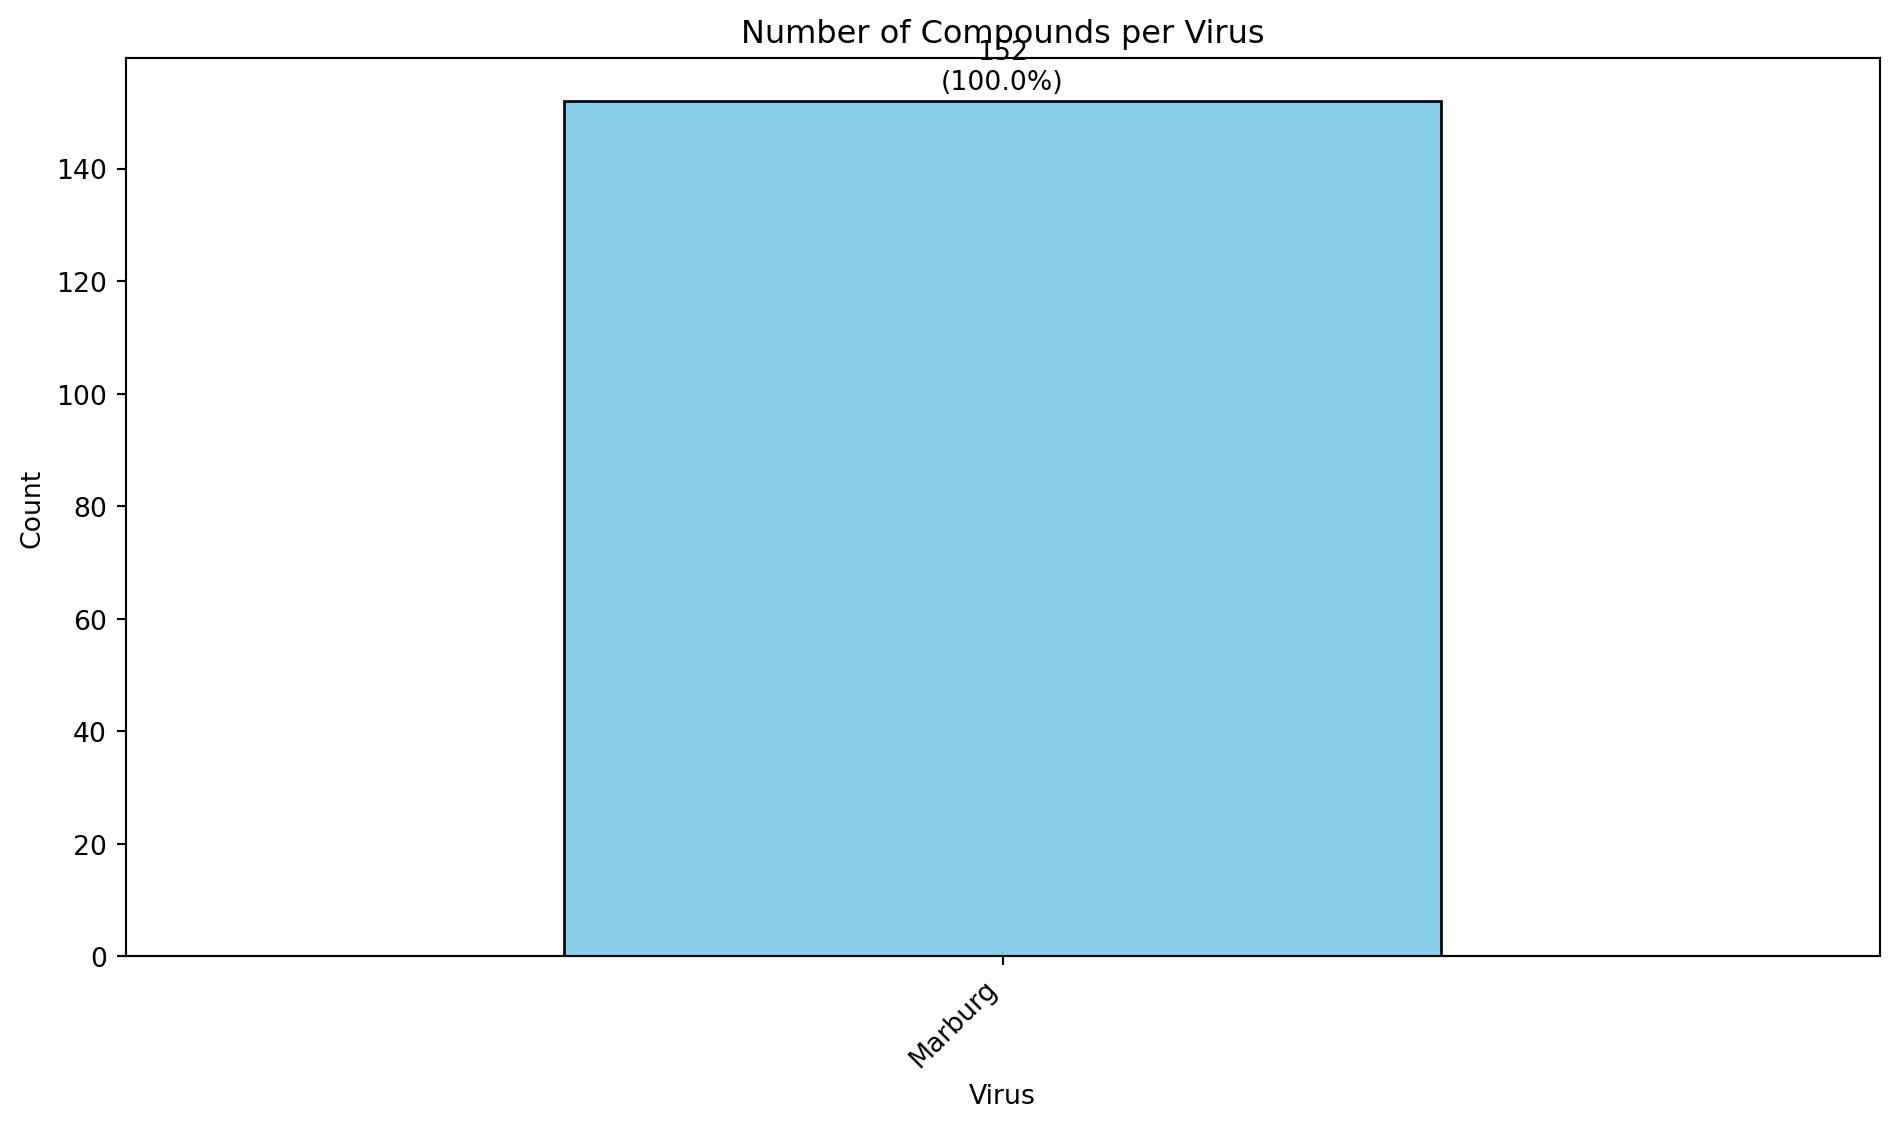

In [269]:
# Get counts and percentages
counts = MarburgVirusData_chEMBL_noDuplicates['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [270]:
MarburgVirusData_chEMBL_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "MarburgVirusData_chEMBL_noDuplicates_MLready.csv"), index=False)

### pPotency value distribution across each Virus

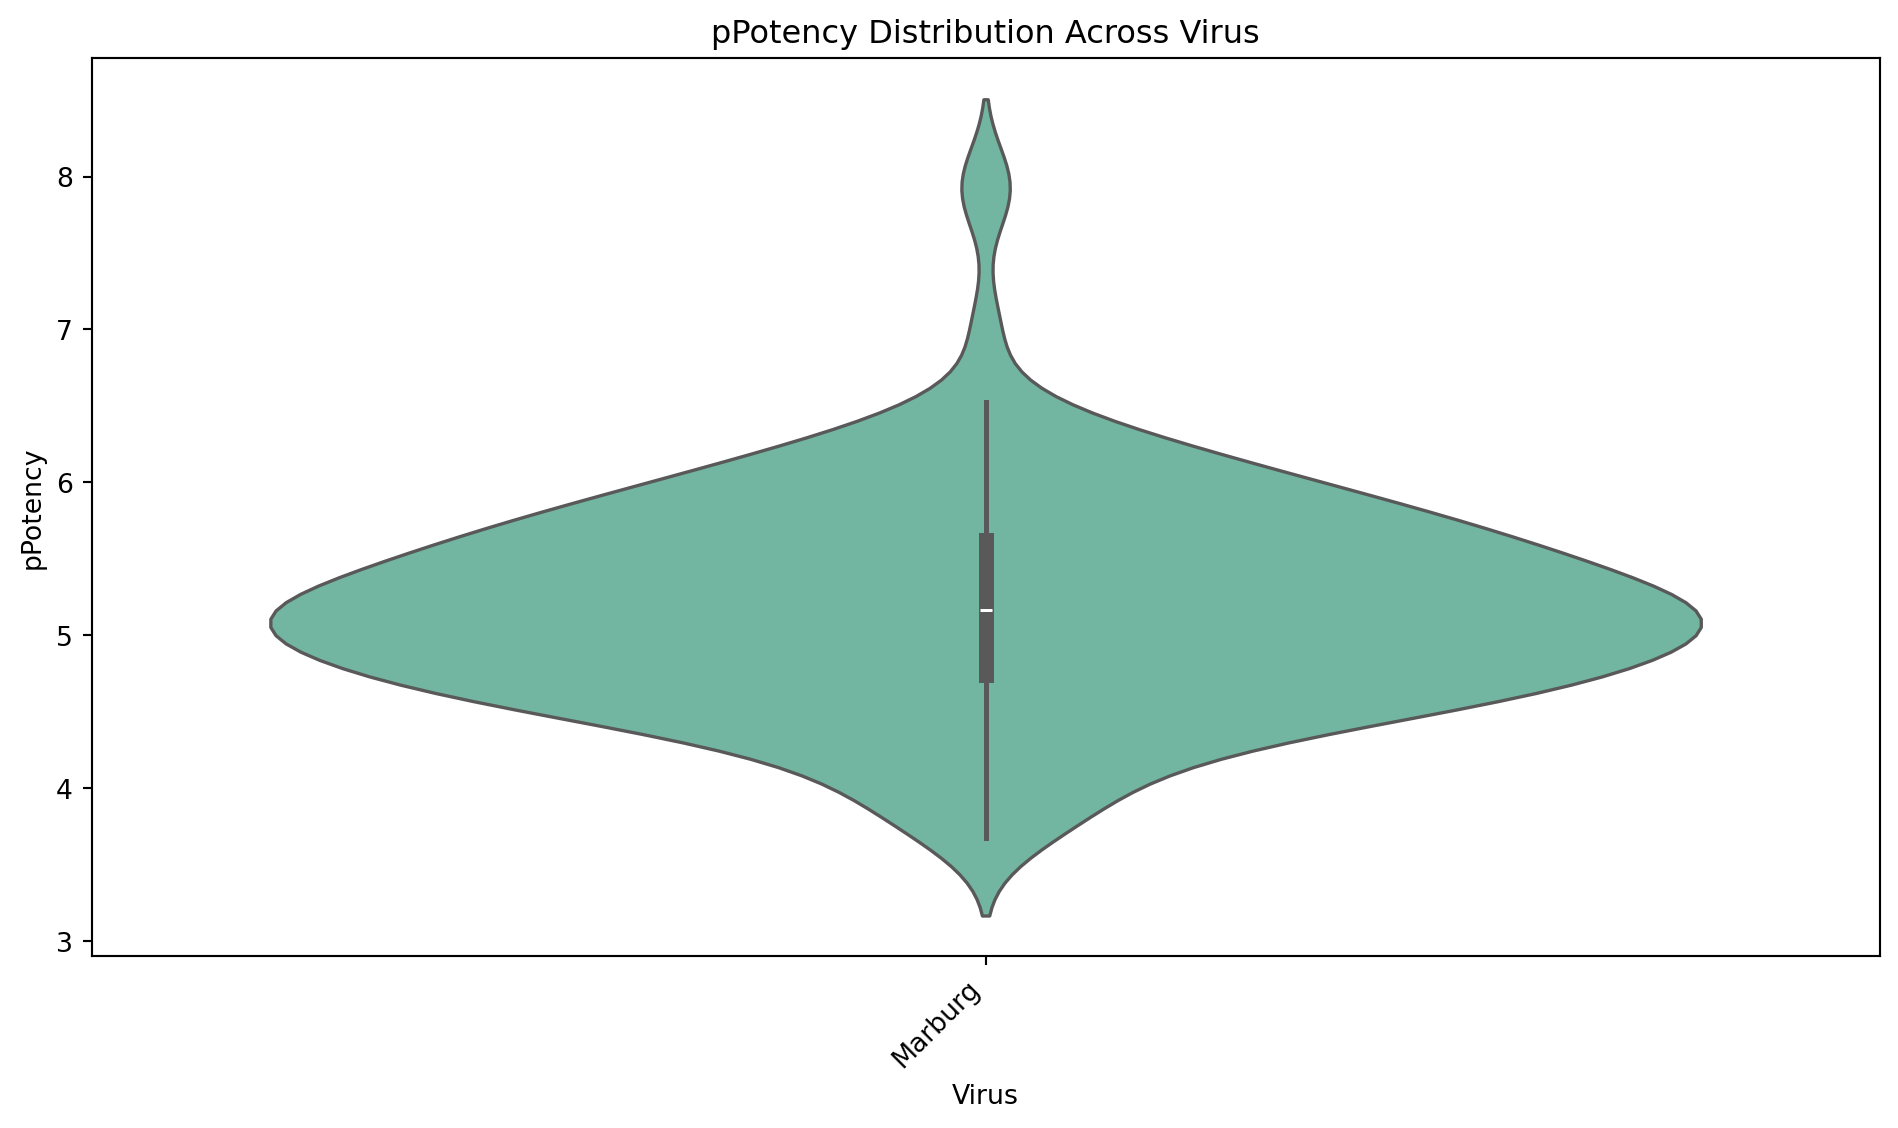

In [271]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=MarburgVirusData_chEMBL_noDuplicates,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

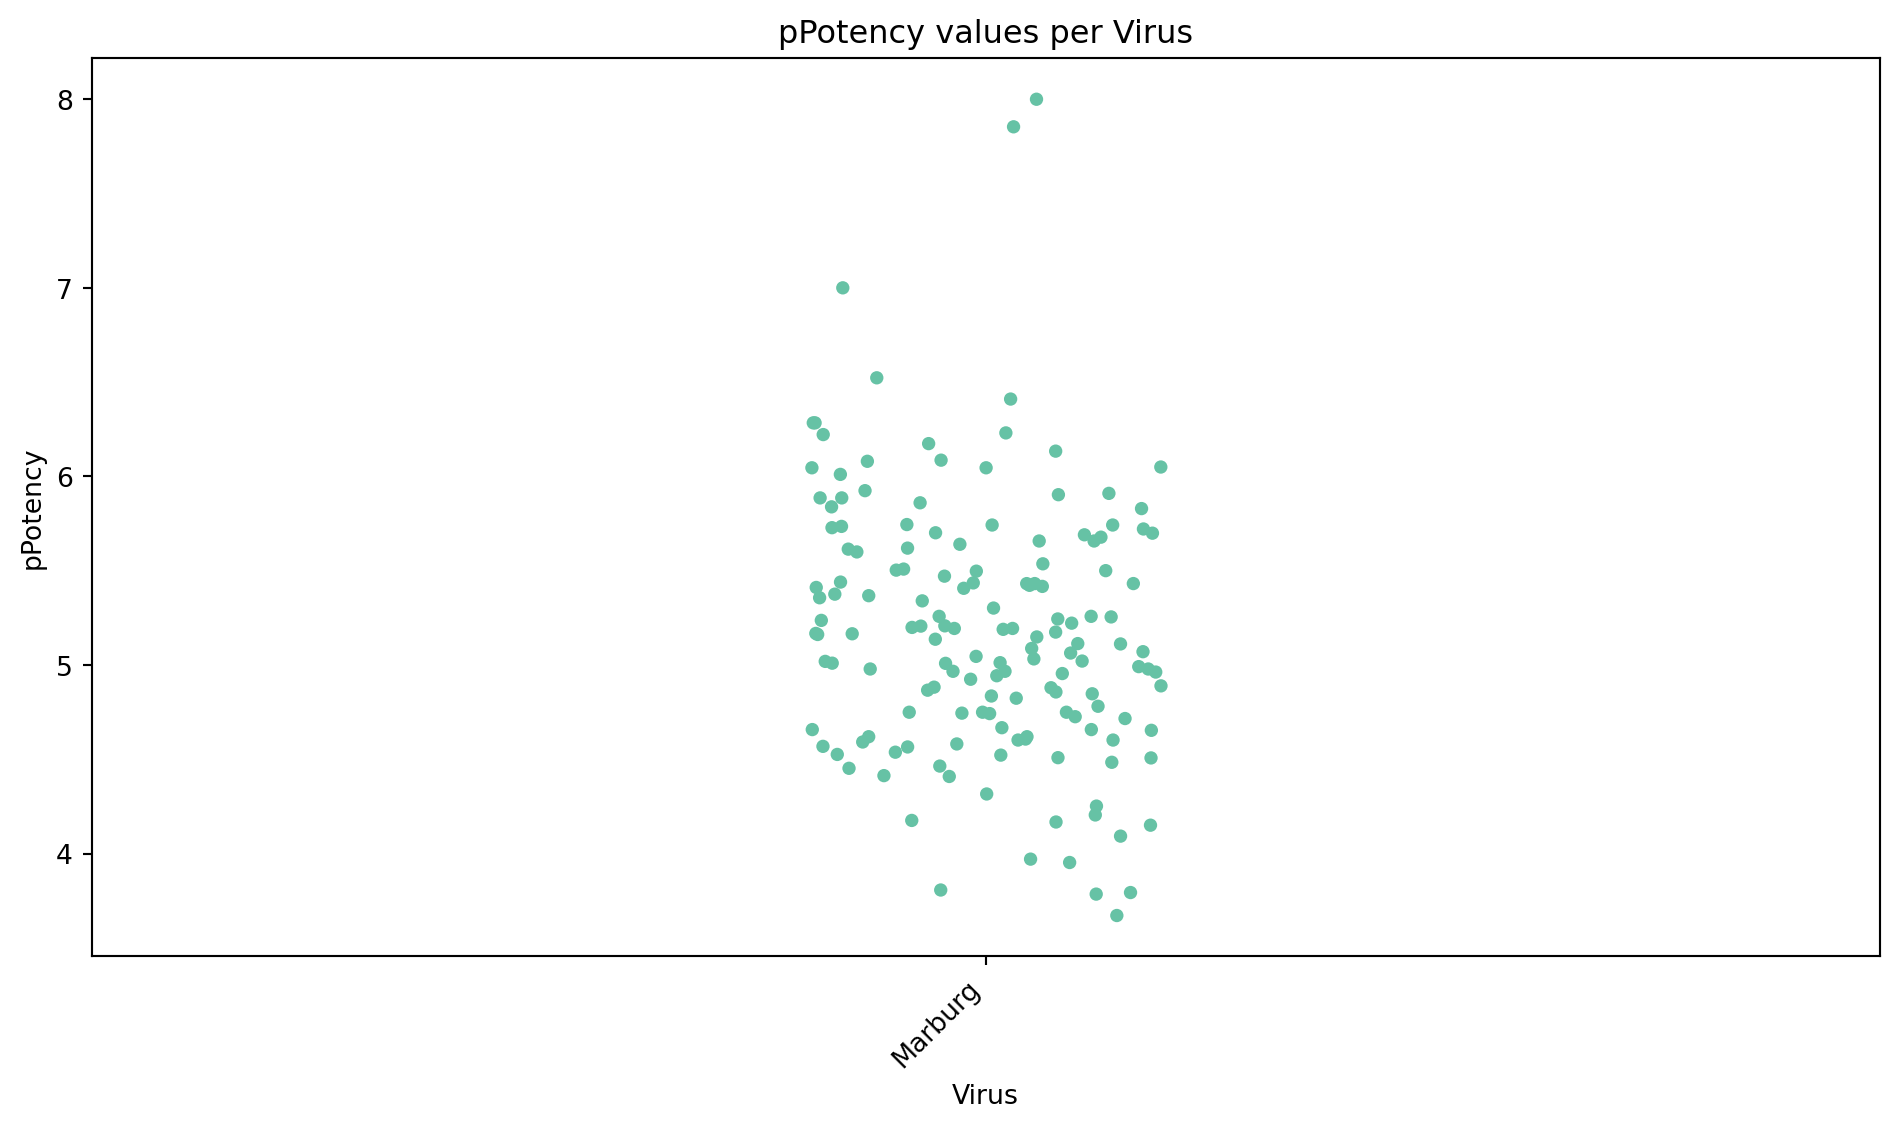

In [272]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=MarburgVirusData_chEMBL_noDuplicates,
    x='VirusClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Create MACAW embeedings to run ART

In [273]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=150, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(MarburgVirusData_chEMBL_noDuplicates['Smiles'], MarburgVirusData_chEMBL_noDuplicates['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "MarburgVirusData_chEMBL_noDuplicates_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(MarburgVirusData_chEMBL_noDuplicates['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=MarburgVirusData_chEMBL_noDuplicates.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
MarburgVirusData_chEMBL_noDuplicates_wMACAW = pd.concat([MarburgVirusData_chEMBL_noDuplicates, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {MarburgVirusData_chEMBL_noDuplicates.shape}")
print(f"New dataframe shape: {MarburgVirusData_chEMBL_noDuplicates_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
MarburgVirusData_chEMBL_noDuplicates_wMACAW.head()

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/MarburgVirusData_chEMBL_noDuplicates_MACAW_transformer.joblib
MACAW embeddings shape: (152, 15)

Original dataframe shape: (152, 3)
New dataframe shape: (152, 18)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15']


,Smiles,VirusClassifier,pPotency,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,MACAW_10,MACAW_11,MACAW_12,MACAW_13,MACAW_14,MACAW_15
0,C#CN(CCCC1(C)N=N1)C(=O)[C@]12CCC(C)(C)C[C@H]1C...,Marburg,5.258061,0.096294,0.040081,-0.020653,0.027424,-0.098208,0.212749,-0.035756,0.162738,0.059961,-0.062915,0.122243,-0.127403,0.066208,-0.012460,0.099996
1,C1=C2CCCN(Cc3ccccc3)[C@H]2[C@@H]2C[C@H]1[C@H]1...,Marburg,4.657577,0.020111,0.053989,0.447802,0.001634,0.037832,-0.093335,-0.070373,-0.016661,0.045187,-0.119356,-0.054247,0.035113,-0.043630,0.076878,0.023473
2,C1=C2CCCN[C@H]2[C@@H]2C[C@H]1[C@H]1CCCCN1C2,Marburg,4.991400,0.135951,0.030387,0.221888,0.096208,0.012261,-0.098418,-0.088165,0.018272,-0.033093,-0.049862,-0.087238,-0.023511,-0.115865,-0.047232,0.059802
3,C=C(C)O[C@@H]1[C@@H](OC(C)=O)[C@H](NC(=O)[C@]2...,Marburg,5.640165,0.027566,0.105004,-0.040220,0.040741,-0.092969,0.227915,-0.065115,0.230053,0.023518,-0.052013,0.171743,-0.080571,0.016339,-0.094676,0.136973
4,CC(C)(C)c1ccc(NC(=O)c2ccc(CN3CCCCC3)cc2)c(C(C)...,Marburg,5.698970,-0.098096,0.069197,-0.018665,0.014405,-0.178911,0.066159,0.044314,-0.187857,0.165078,0.064023,0.147057,-0.088691,-0.045974,0.010877,0.029217


In [274]:
MarburgVirusData_chEMBL_noDuplicates_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "MarburgVirusData_chEMBL_noDuplicates_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [88]:
# df = MarburgVirusData_chEMBL_noDuplicates
Y = MarburgVirusData_chEMBL_noDuplicates.pPotency
smiles = MarburgVirusData_chEMBL_noDuplicates.Smiles

In [89]:
print(len(smiles))

152


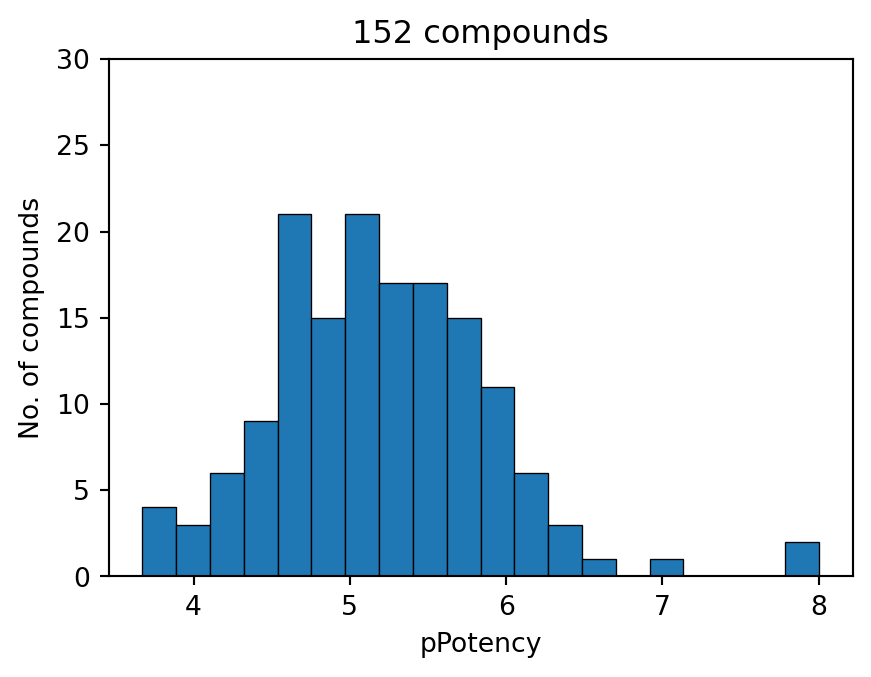

In [90]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [91]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [92]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [93]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [94]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 152 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [95]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.26
  RMSE: 0.37
  R²:   0.71
Test Set:
  MAE:  0.35
  RMSE: 0.50
  R²:   0.47

Best params (sample): [{'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}]
CPU times: user 105 ms, sys: 24.4 ms, total: 130 ms
Wall time: 6.52 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_CV_TrTs.png


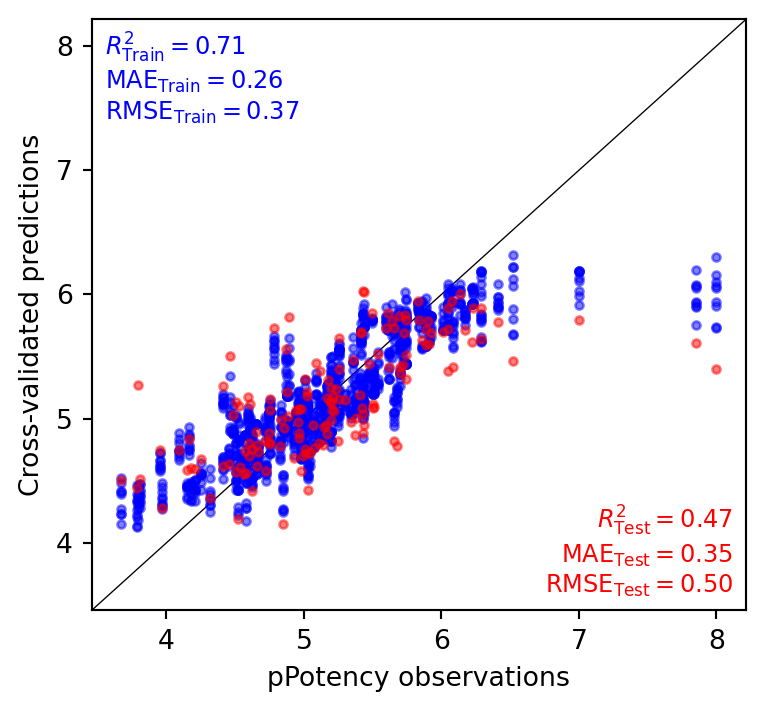

In [96]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/MarburgVirus_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [97]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(smiles, Y)

In [98]:
X_all = mcw.transform(smiles)
X_all.shape

(152, 15)

Training samples: 121
Test samples: 31
Feature dimensions: 15

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 1
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.36

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.73            0.37            0.36           
MAE        0.23            0.42            0.19           
RMSE       0.34            0.59            0.25           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/us

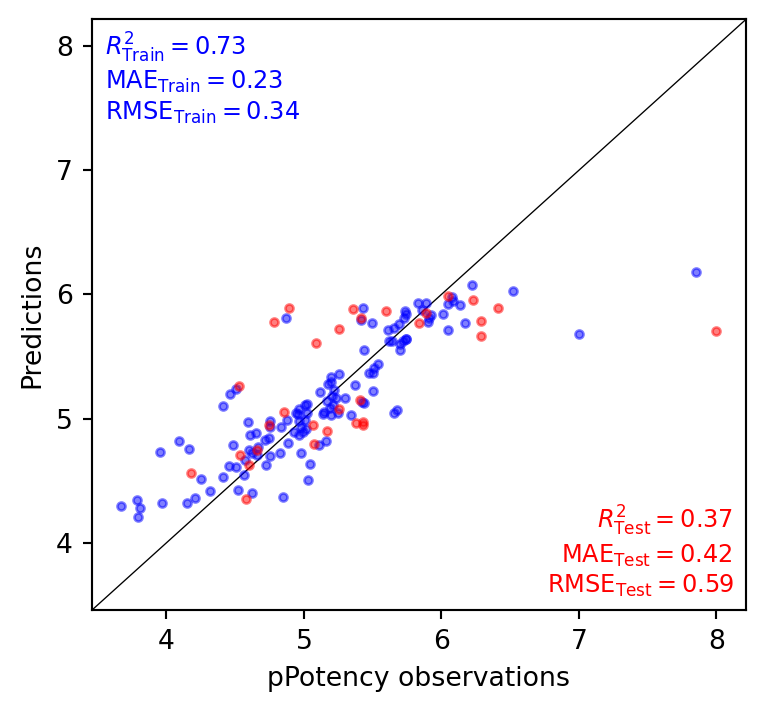

CPU times: user 939 ms, sys: 68 ms, total: 1.01 s
Wall time: 1.36 s


In [99]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/MarburgVirus_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [100]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = MarburgVirusData_chEMBL.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 152
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.140,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.720,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.700,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.370,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.880,7,https://real.enamine.net/public-enum-files/Z38...


Generate predictions

In [101]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [102]:
EnamineAntiviralsData_predicted = EnamineAntiviralsData.copy()
EnamineAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-EnamineAntiviralsData_predicted['pPotency_prediction'])

EnamineAntiviralsData_predicted = EnamineAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
EnamineAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,5.325,4.727e-06
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,5.185,6.525e-06
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,5.101,7.930e-06
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,5.239,5.765e-06
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,5.141,7.221e-06
...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,5.320,4.786e-06
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,5.496,3.188e-06
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,5.129,7.422e-06
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,5.319,4.793e-06


Let us represent the predictions of both models:

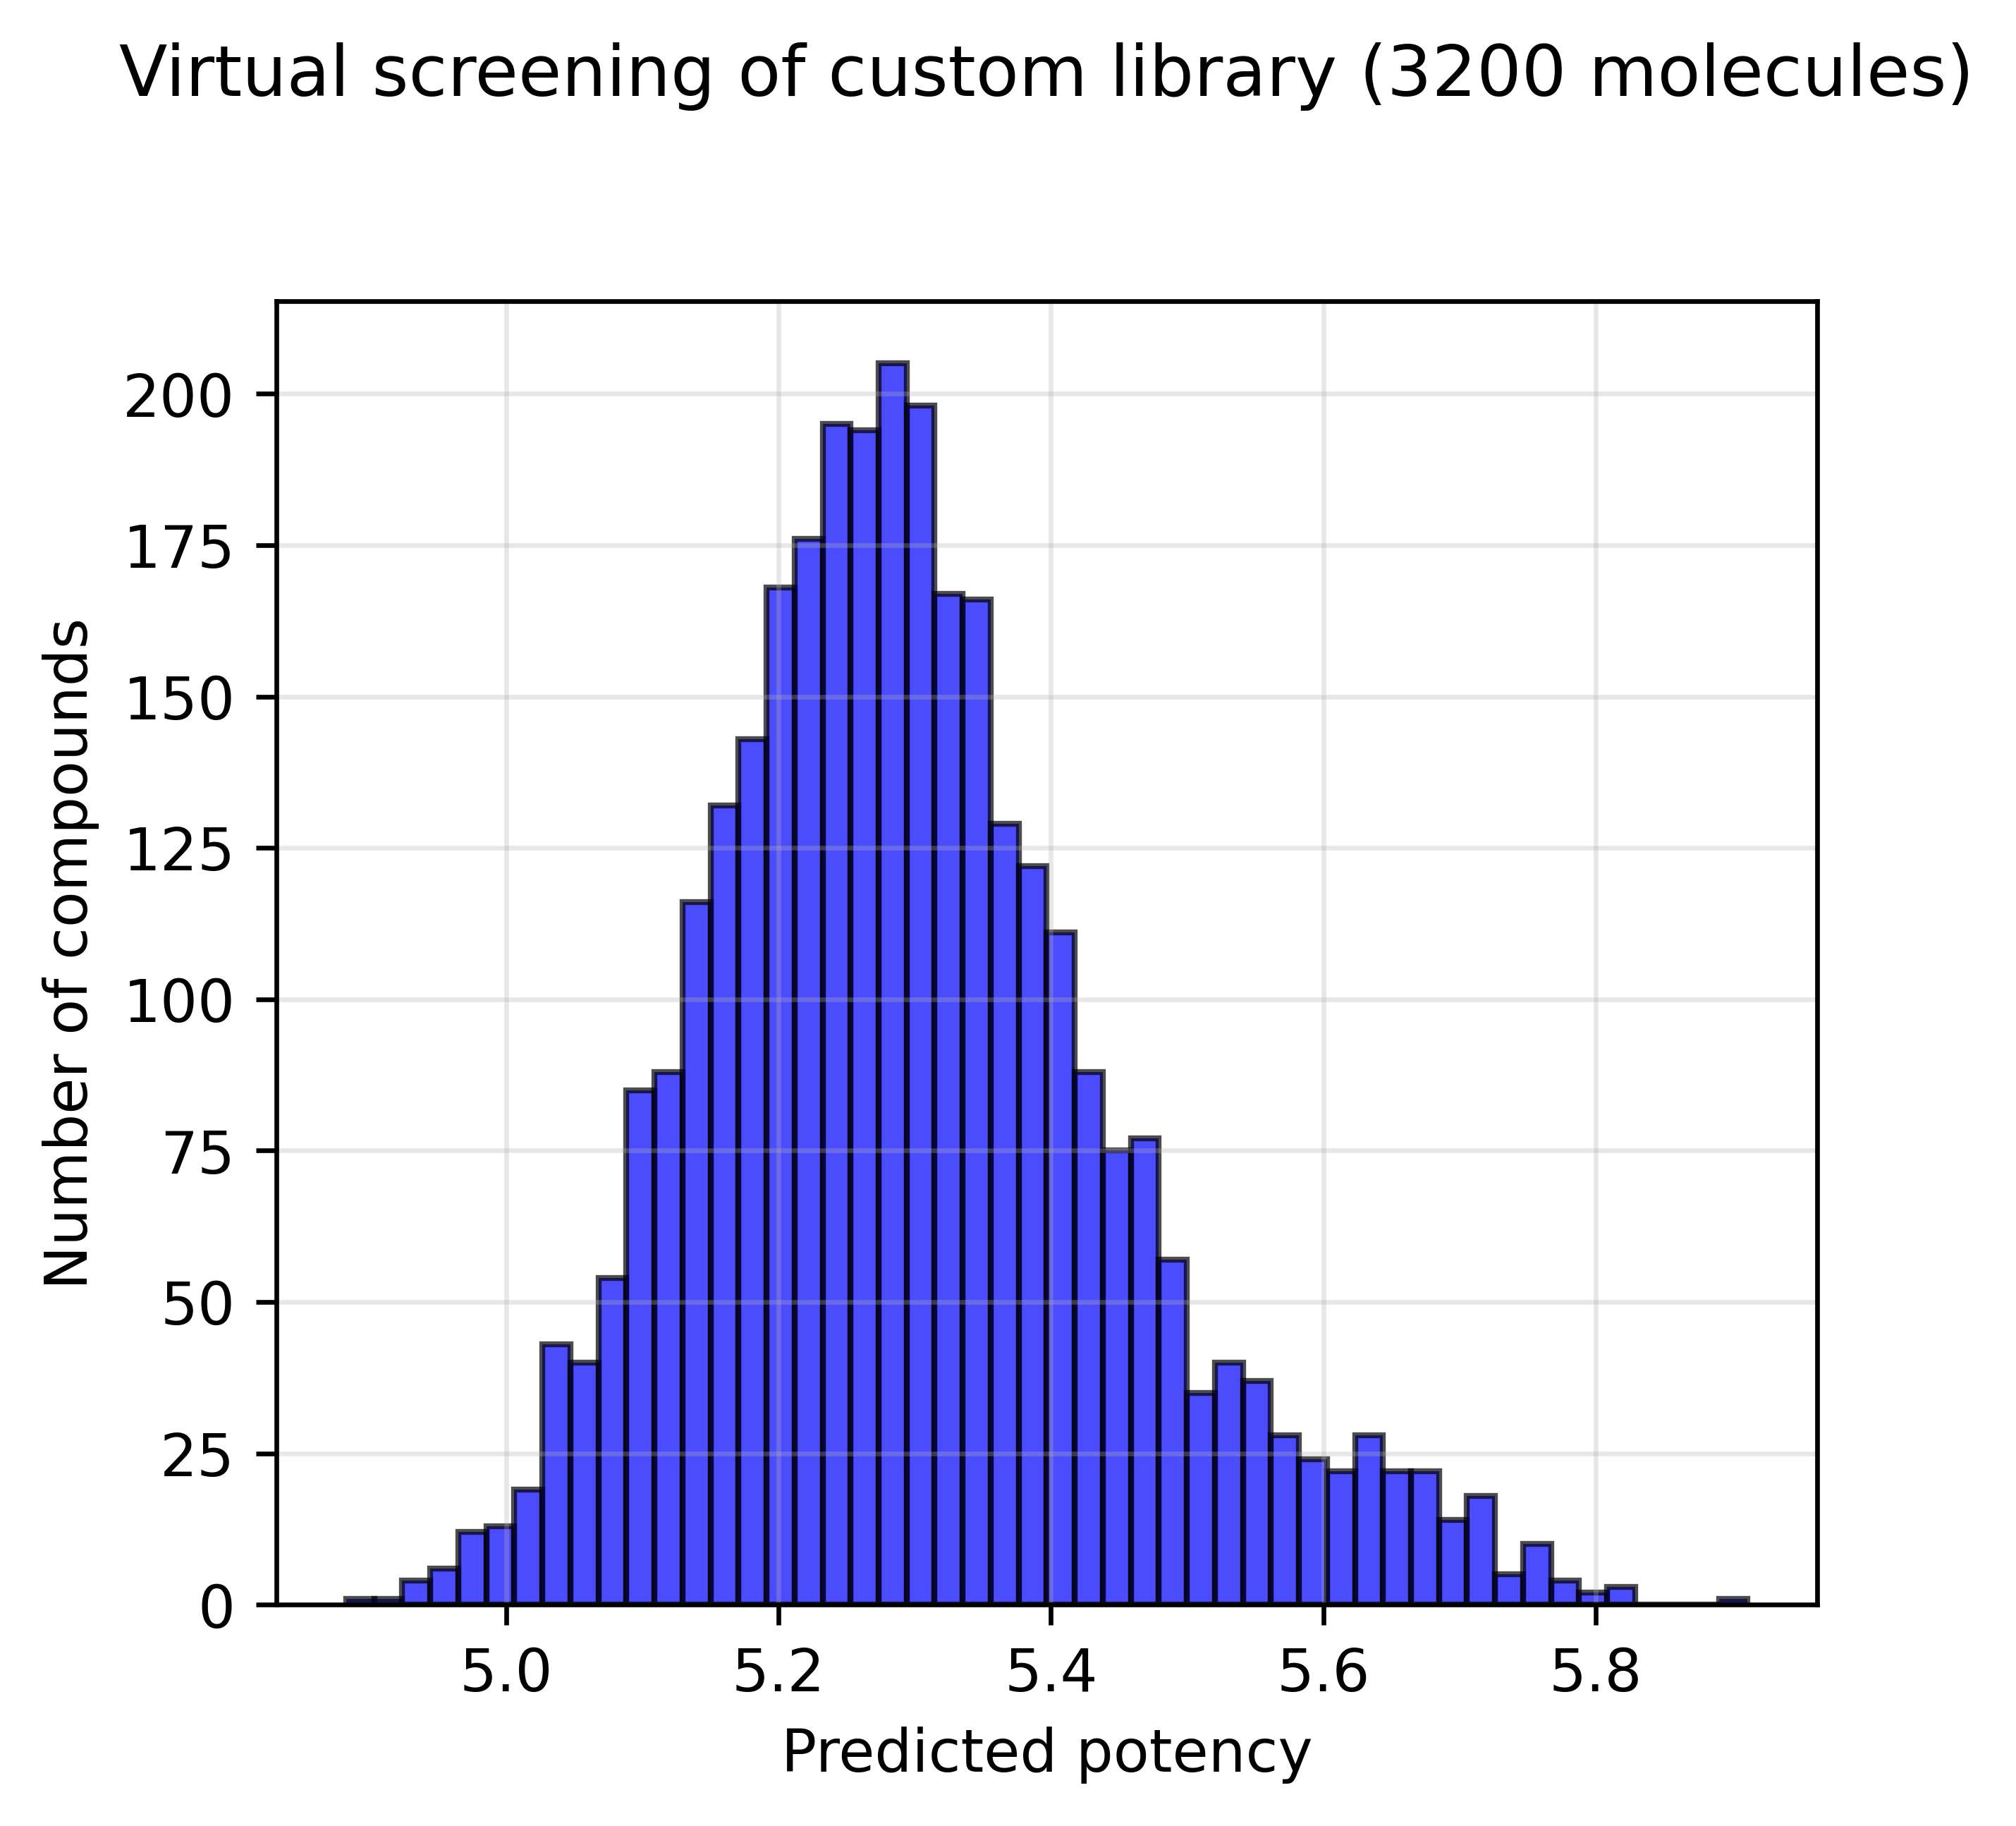

In [103]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/MarburgVirus_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/MarburgVirus_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [104]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 3164 compounds


In [105]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Top 20 compounds with higher pPotency

In [106]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.75
Highest predicted pPotency: 5.91
Range of top 20: 5.75 - 5.91


In [107]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.748
  IC50:        1.788e-06 M  (1788.44 nM)

Best Values (1st ranked compound):
  pPotency:    5.911
  IC50:        1.227e-06 M  (1226.99 nM)
Range for Top 20 Compounds:
pPotency Range:  5.748 - 5.911

IC50 Range (M):  1.788e-06 - 1.227e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
2636,1,CC(=O)NC=1C=CC(=CC1)OCC(O)CN2C(C)=NC=3C=CC=CC32,5.911,1.227e-06
2530,2,CC(=O)N[C@@H](C)C1=NC=2C=CC=CC2N1CC(O)C3=CC=CC...,5.817,1.523e-06
2485,3,CCC(=O)C=1C=CC(=CC1)OCC(O)CN2C=NC3=CC=CC=C32,5.815,1.531e-06
1043,4,CCN1C(=O)N(CC(O)COC=2C=CC(C#N)=CC2)C=3C=CC=CC31,5.812,1.540e-06
1297,5,CC(=O)C=1C=CC(=CC1)OCC(O)CN2C(C)=NC=3C=CC=CC32,5.799,1.587e-06
2618,6,CC(=O)NC(C)C1=NC=2C=CC=CC2N1CC(O)C=3C=CC=CC3,5.799,1.587e-06
2744,7,COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32,5.787,1.634e-06
1355,8,CC1=NC=2C=CC=CC2N1CC(O)C=3C=CC(=CC3)OC(F)F,5.776,1.673e-06
2880,9,COC=1C=C(C=CC1OCC(O)CN2C=NC=3C=CC=CC32)C(C)=O,5.773,1.687e-06
2030,10,COC=1C=CC(OC)=C(C1)C(O)CN2C(=O)N(C)C=3C=CC=CC32,5.768,1.707e-06


In [108]:
EnamineAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_noDuplicates_predictedCompounds.svg


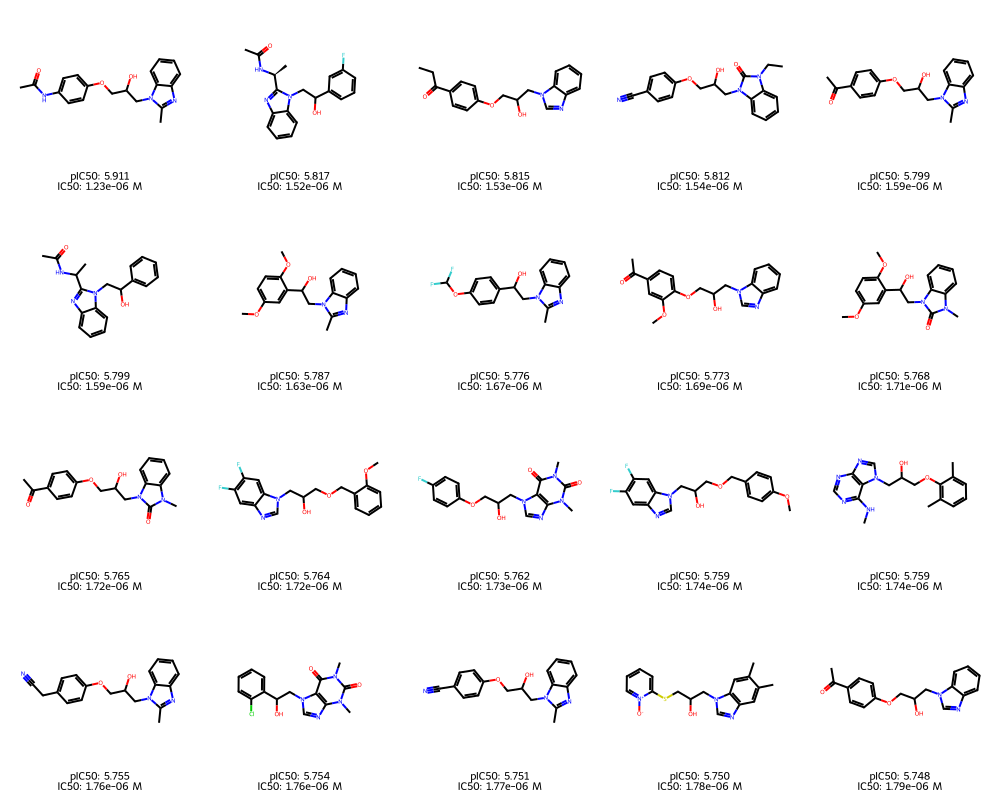

In [109]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + '/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_noDuplicates_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_noDuplicates_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [110]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 152
Filtered LifeChemicals data shape for validation: (45573, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45573


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.500,274.360,solid,0.690,-0.120,32.780,2,1,1,20.000,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.500,301.260,solid,0.620,2.030,66.320,4,1,2,21.000,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.000,205.300,oil,0.580,0.890,19.370,3,3,2,15.000,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.500,261.320,oil,0.640,2.090,66.320,4,1,2,19.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.500,218.290,solid,0.670,0.790,41.050,2,2,3,16.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1


Generate predictions for the H1 receptor:

In [111]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [112]:
LCAntiviralsData_predicted = LCAntiviralsData_superset.copy()
LCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-LCAntiviralsData_predicted['pPotency_prediction'])

LCAntiviralsData_predicted = LCAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
LCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,4.944,1.137e-05
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,5.294,5.084e-06
2,CN1CCCN(Cc2ccncc2)CC1,5.058,8.754e-06
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,5.229,5.907e-06
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,5.115,7.676e-06
...,...,...,...
45568,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...,5.758,1.744e-06
45569,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....,5.588,2.582e-06
45570,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl,5.611,2.451e-06
45571,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...,5.939,1.150e-06


Let us represent the predictions of both models:

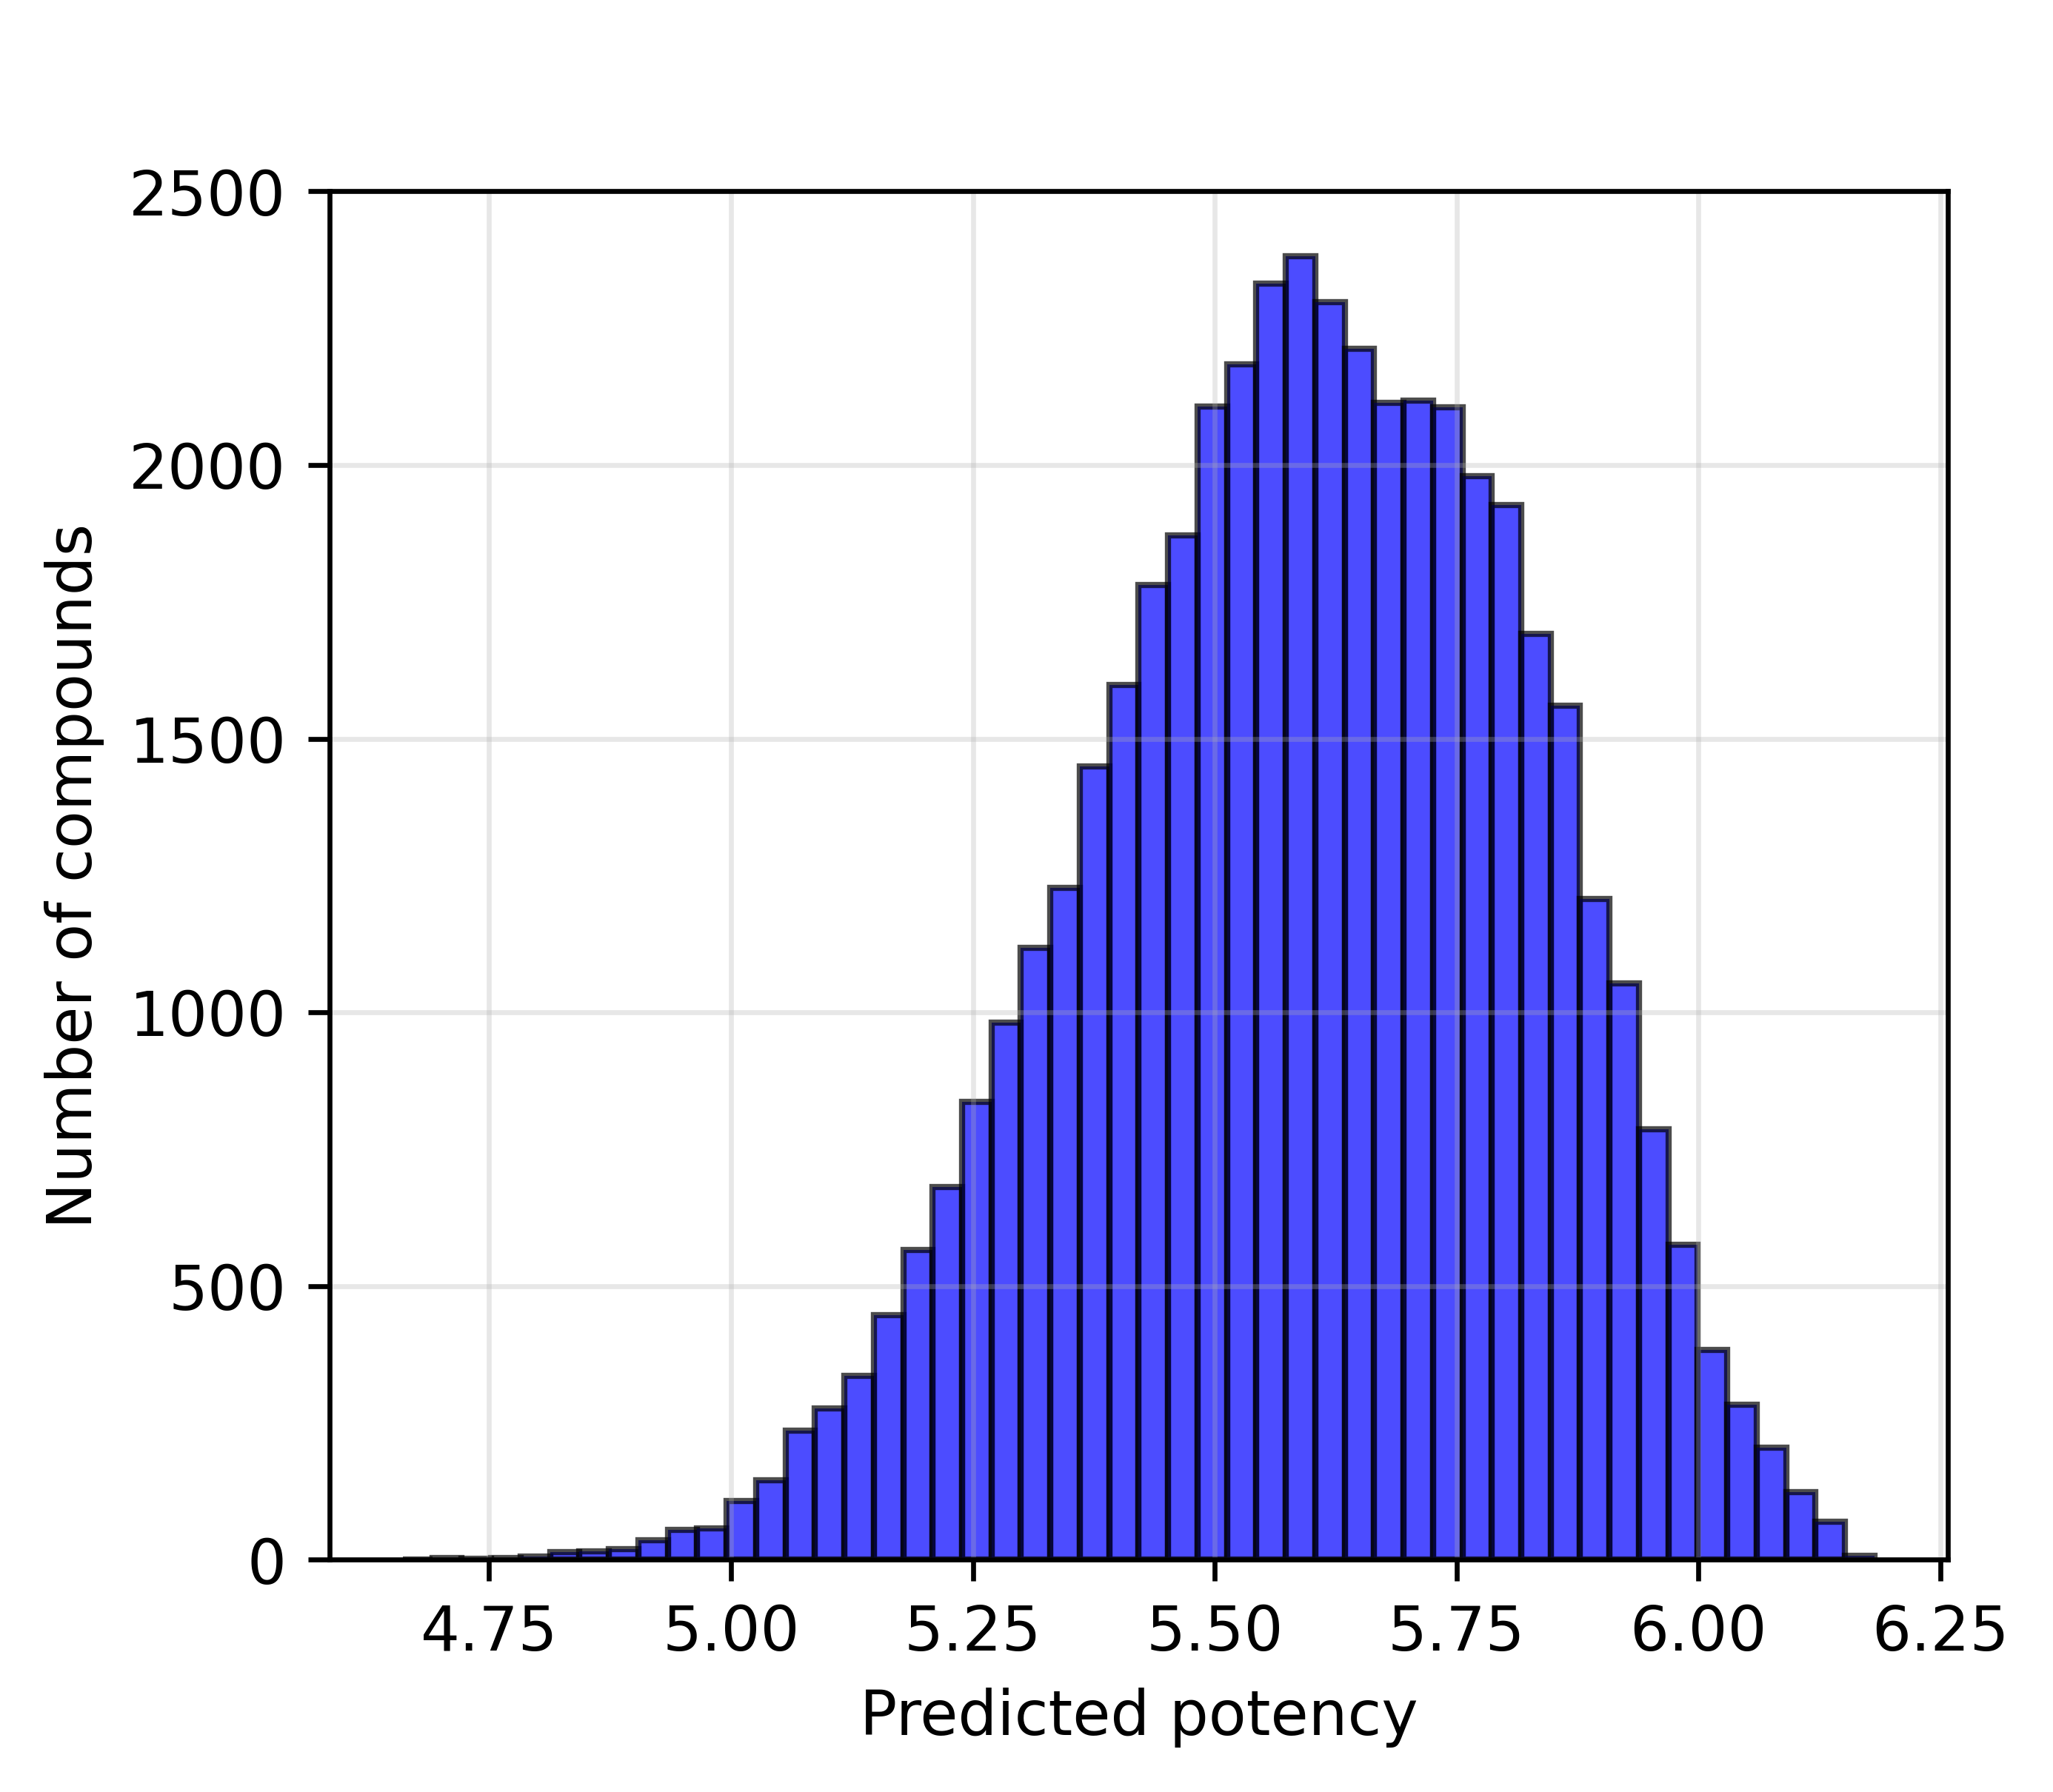

In [113]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/MarburgVirus_validation_noDuplicates_LCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/MarburgVirus_validation_noDuplicates_LCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [114]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 1060 compounds
Low priority (5 ≤ pPotency < 6): 44284 compounds


In [115]:
LCAntiviralsData_superset_final = LCAntiviralsData_superset.iloc[idx].copy()
LCAntiviralsData_superset_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntiviralsData_superset_final = LCAntiviralsData_superset_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntiviralsData_superset_final

,SMILES,pPotency_prediction,clogP


### Top 20 compounds with higher PpPotency

In [116]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.14
Highest predicted pPotency: 6.18
Range of top 20: 6.14 - 6.18


In [117]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_superset.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.143
  IC50:        7.201e-07 M  (720.13 nM)

Best Values (1st ranked compound):
  pPotency:    6.182
  IC50:        6.581e-07 M  (658.11 nM)
Range for Top 20 Compounds:
pPotency Range:  6.143 - 6.182

IC50 Range (M):  7.201e-07 - 6.581e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
40972,1,CCOc1ccc(-n2c(SCC(=O)Nc3ccc(CC)cc3)nnc2-c2c[nH...,6.182,6.581e-07
43774,2,CCOC(=O)c1ccc(NC(=O)CSc2nnc(CNC(=O)c3ccc(S(=O)...,6.165,6.836e-07
43812,3,CN(C)c1ccc(NC(=O)CSc2nc3cc4c(cc3c(=O)n2Cc2ccc(...,6.162,6.885e-07
43802,4,CCc1ccc(NC(=O)CSc2nc3cc4c(cc3c(=O)n2Cc2ccc(C(=...,6.158,6.946e-07
43071,5,CCOc1ccc(-n2c(CNC(=O)c3ccc(S(=O)(=O)N4CCOCC4)c...,6.157,6.962e-07
42929,6,CCOc1ccc(-n2c(CNC(=O)c3ccc(S(=O)(=O)N4CCCC4)cc...,6.154,7.014e-07
34572,7,CC(C)c1ccc(NC(=O)CSc2nc3ccc(N4CCOCC4)cc3c(=O)n...,6.154,7.020e-07
43842,8,CCCN(CCC)S(=O)(=O)c1ccc(C(=O)Nc2ccccc2C(=O)Nc2...,6.151,7.070e-07
42857,9,CCOc1ccc(-n2c(CNC(=O)c3ccc(S(=O)(=O)N4CCOCC4)c...,6.149,7.096e-07
42832,10,CCOc1ccc(-n2c(SCC(=O)Nc3ccc(CC)cc3)nc3c([nH]c4...,6.147,7.128e-07


In [118]:
LCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_LCDataset.svg


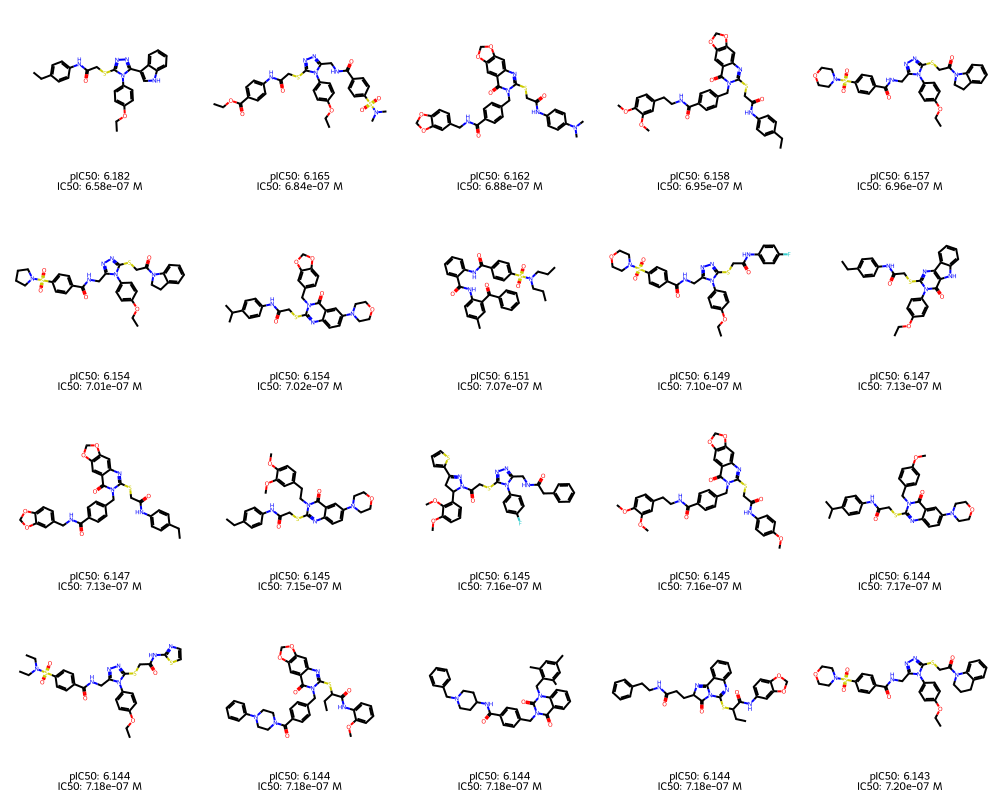

In [119]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + '/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.3 Discovery of new hits specific to all viruses (data source `chemDiv` data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [120]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 152
Filtered ChemDiv data shape for validation: (64958, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64958


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,...,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.000,4.584,3.825,-4.736,44.193,...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.300,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.000,2.084,1.279,-2.867,59.381,...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.000,4.274,3.444,-4.355,53.078,...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.000,3.231,3.225,-3.423,79.491,...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.200,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.000,5.054,5.054,-5.469,49.877,...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.000,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.000,6.685,3.100,-6.678,70.818,...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.800,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.000,6.551,3.884,-5.738,62.323,...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.000,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.000,6.014,2.429,-5.464,64.713,...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.300,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.000,6.905,6.387,-6.761,57.369,...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.600,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


Generate predictions for the H1 receptor:

In [121]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

50000


In [122]:
ChemDivAntiviralsData_predicted = ChemDivAntiviralsData.copy()
ChemDivAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-ChemDivAntiviralsData_predicted['pPotency_prediction'])

ChemDivAntiviralsData_predicted = ChemDivAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
ChemDivAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,5.565,2.723e-06
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,5.259,5.513e-06
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,5.469,3.396e-06
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,5.631,2.340e-06
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,5.620,2.398e-06
...,...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,5.974,1.061e-06
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,5.993,1.017e-06
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.921,1.198e-06
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,5.982,1.042e-06


Let us represent the predictions of both models:

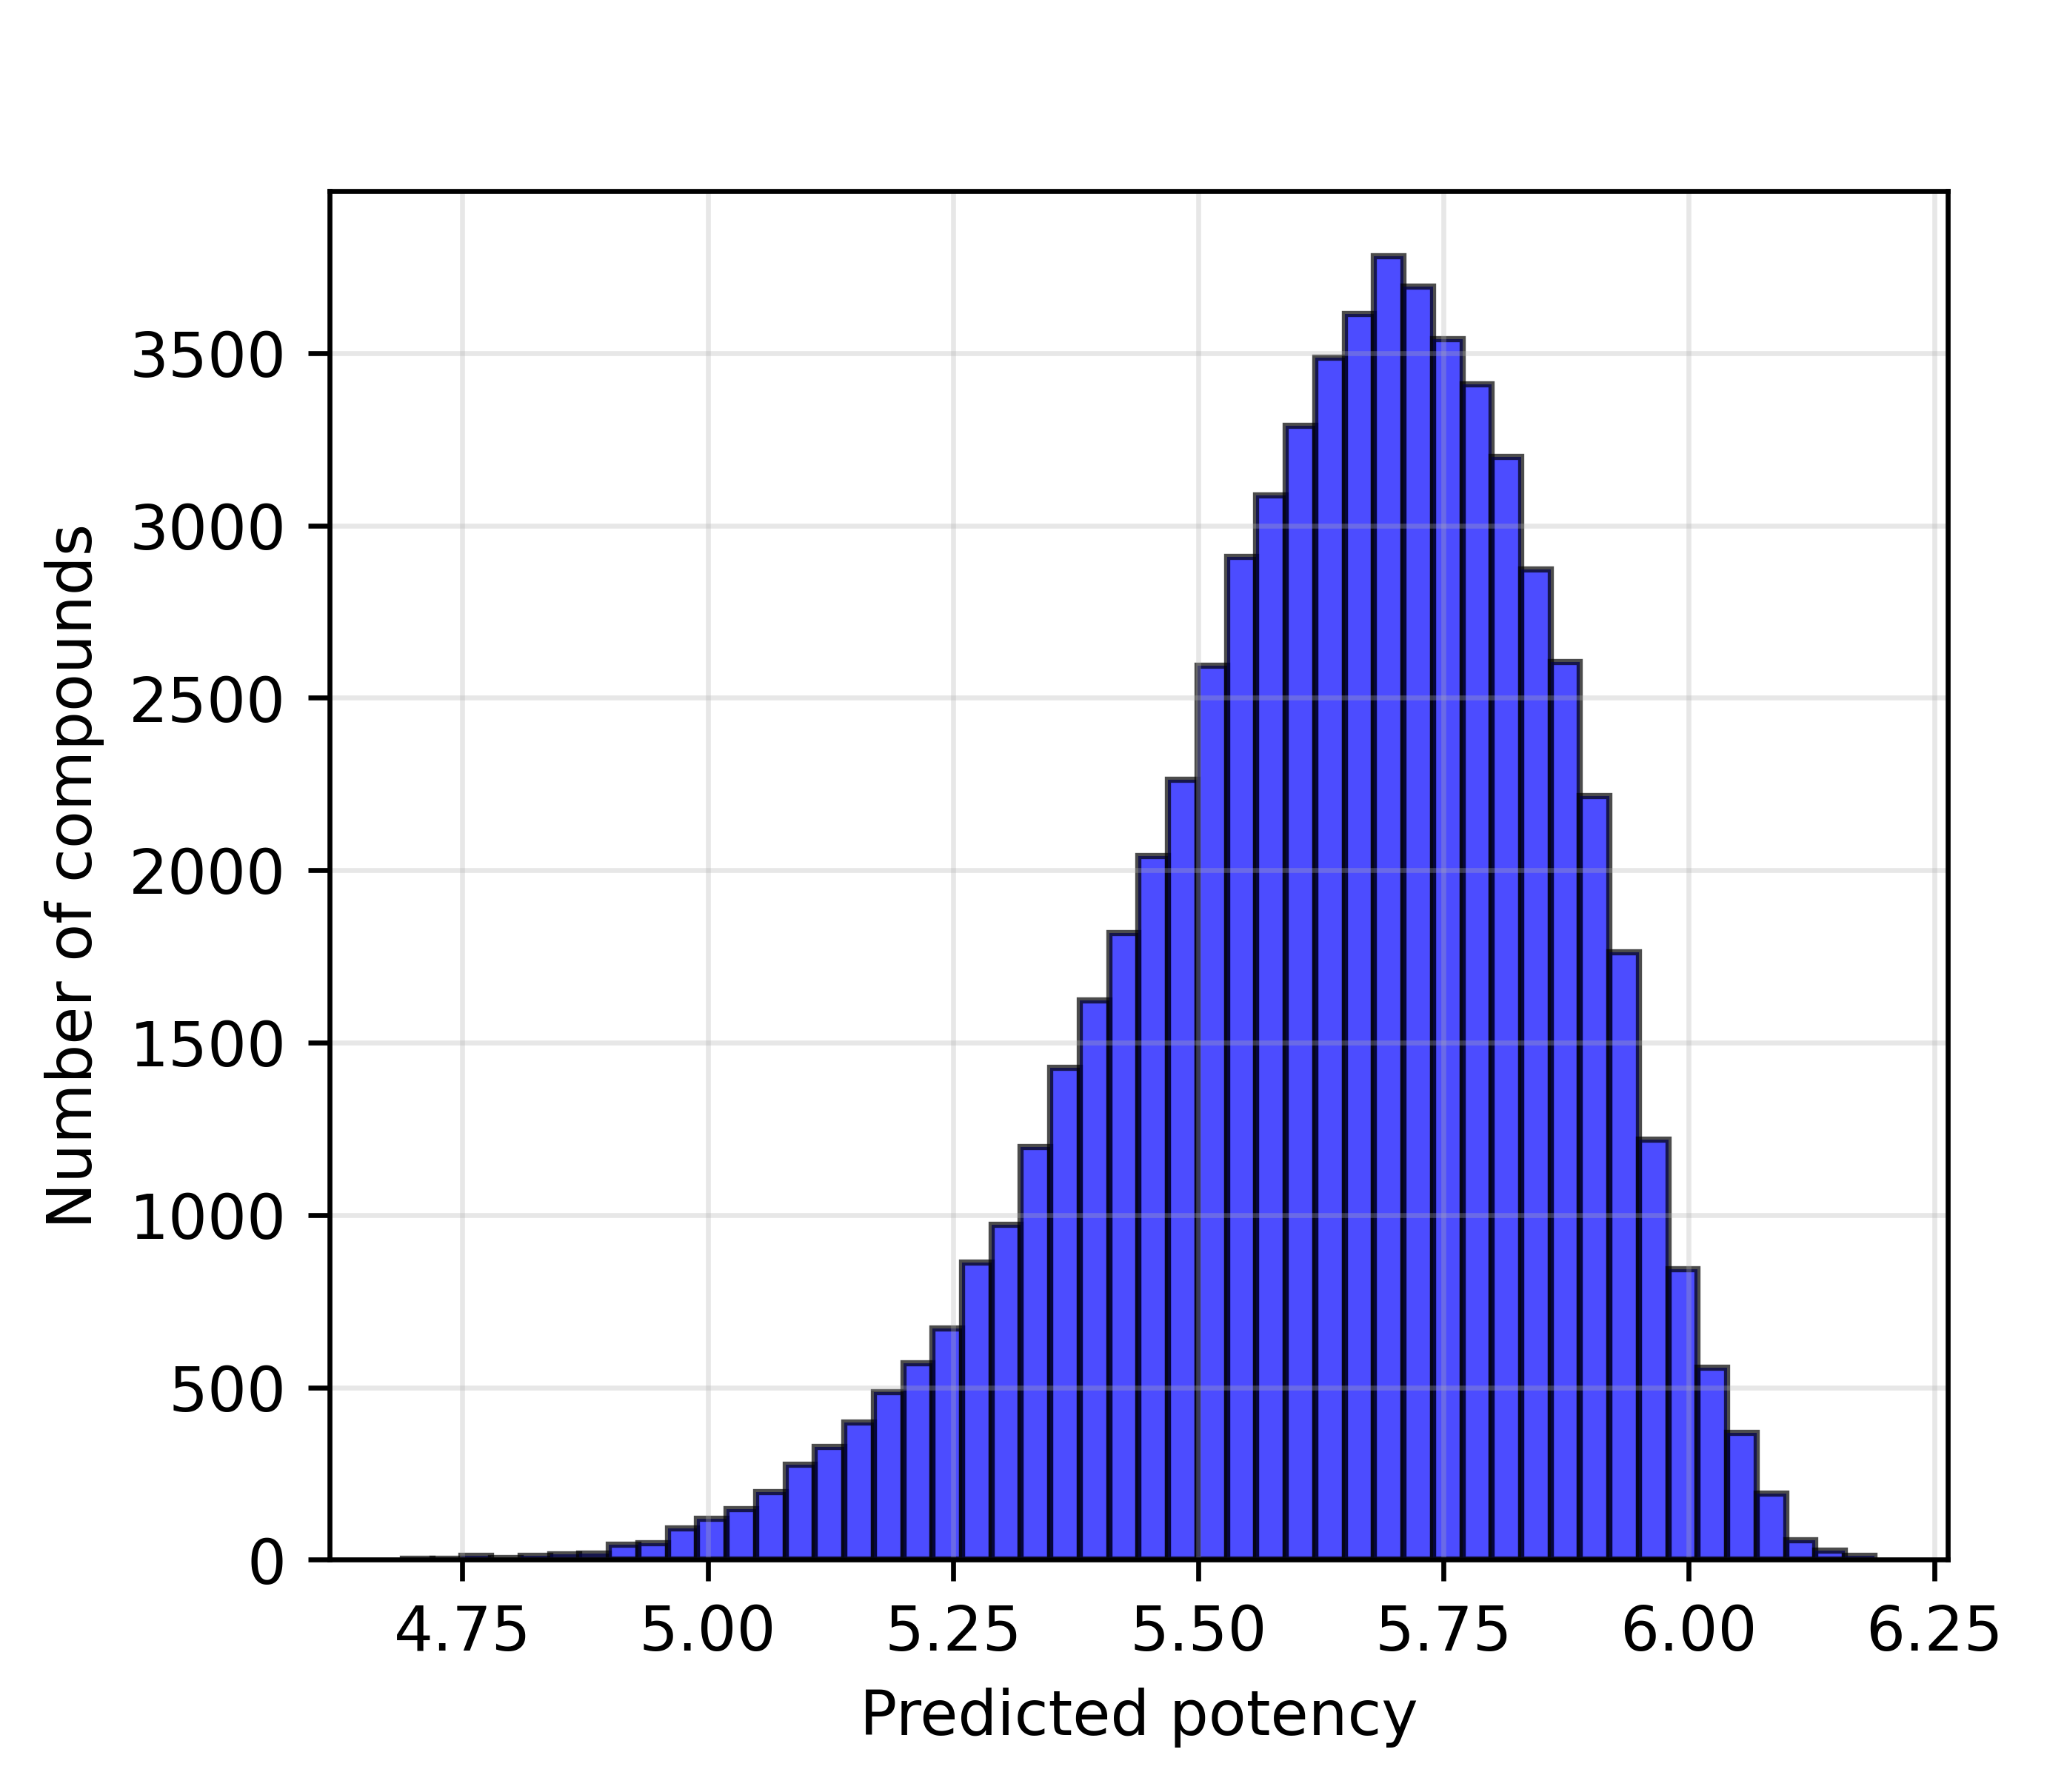

In [123]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/MarburgVirus_validation_noDuplicates_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/MarburgVirus_validation_noDuplicates_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [124]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 1442 compounds
Low priority (5 ≤ pPotency < 6): 63223 compounds


In [125]:
ChemDivAntiviralsData_final = ChemDivAntiviralsData.iloc[idx].copy()
ChemDivAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiviralsData_final = ChemDivAntiviralsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiviralsData_final

,SMILES,pPotency_prediction


### Top 20 compounds with higher PpPotency

In [126]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.15
Highest predicted pPotency: 6.19
Range of top 20: 6.15 - 6.19


In [127]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.147
  IC50:        7.130e-07 M  (713.00 nM)

Best Values (1st ranked compound):
  pPotency:    6.189
  IC50:        6.471e-07 M  (647.07 nM)
Range for Top 20 Compounds:
pPotency Range:  6.147 - 6.189

IC50 Range (M):  7.130e-07 - 6.471e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
36666,1,CCC(C)NS(=O)(=O)c1cc(NC(=O)C2CCCC2)ccc1Oc1c(C)...,6.189,6.471e-07
1055,2,CCC(C)NS(=O)(=O)c1cc(NC(=O)C2CCCC2)ccc1Oc1c(C)...,6.181,6.598e-07
48563,3,CCOc1ccc(C(=O)CSc2nnc3n(C)c(=O)c4ccc(C(=O)NC5C...,6.168,6.792e-07
47993,4,CCC(C)NC(=O)c1ccc2c(=O)n(C)c3nnc(SCc4ccc(N5CCC...,6.167,6.803e-07
44003,5,CCOc1ccc(C(=O)CSc2nnc3n(C)c(=O)c4ccc(C(=O)NC5C...,6.166,6.824e-07
4418,6,COc1ccc(-n2ncc(Oc3ccc4c(c3)CCC4)c(Nc3cccc(C(=O...,6.164,6.861e-07
4858,7,CC1CCN(S(=O)(=O)c2ccc3nc(-c4cccnc4)cc(C(=O)NC(...,6.163,6.868e-07
47283,8,Cc1ccccc1-n1nc(C(=O)O)c(C)c1Oc1ccc(NC(=O)C2CCC...,6.162,6.889e-07
36664,9,CCC(C)NS(=O)(=O)c1cc(NC(=O)c2cccs2)ccc1Oc1c(C)...,6.162,6.889e-07
56701,10,CC(C)c1ccc(Nc2cc(C(=O)NC(C)c3ccc4c(c3)OCCO4)c3...,6.162,6.891e-07


In [128]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_ChemDivDataset.svg


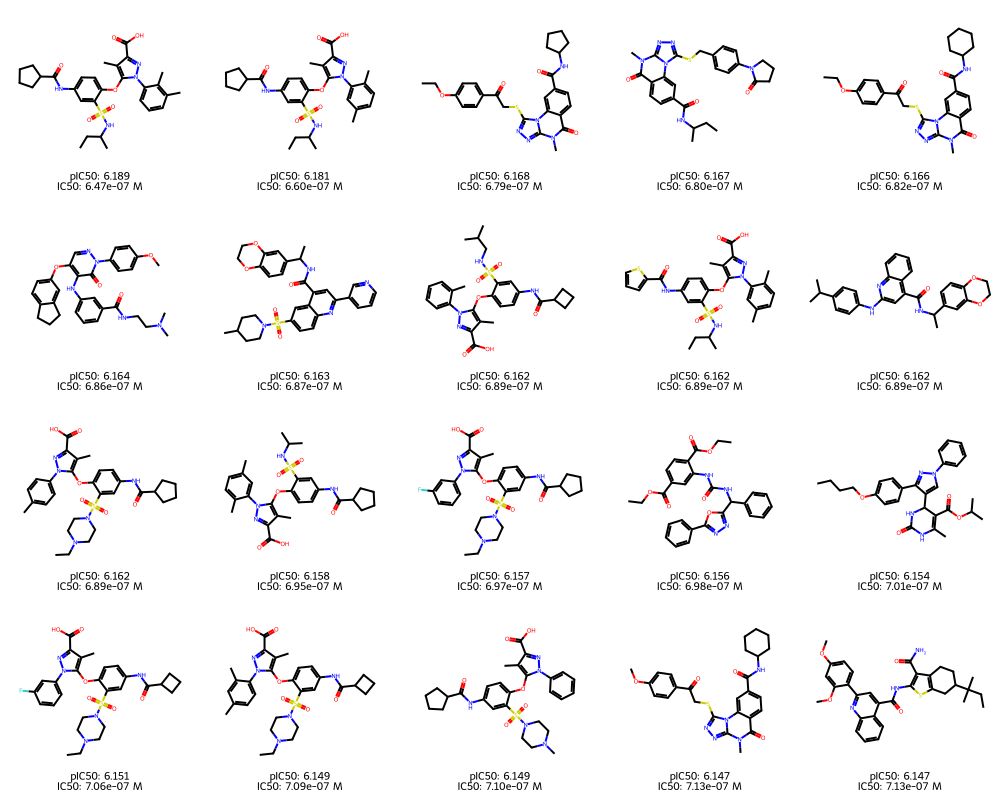

In [129]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + '/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source `SMACC` Antivirals data set)
In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [130]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
SMACCAntiviralsData.head()

Original SMACC data shape: (1923, 5), with Duplicate SMILES: 197
After removing internal duplicates: (1612, 4)
Number of unique SMILES in training set: 152
Filtered SMACC data shape for validation: (1612, 4)
Removed 0 duplicate compounds from SMACC data set
Total compounds to screen: 1612


,SMILES,Molecule ChEMBL ID,pIC50_experimental,Virus
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,CHEMBL243652,5.690,SARS-CoV-2
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,CHEMBL4284511,5.328,Dengue
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,CHEMBL1402117,4.132,Dengue
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,CHEMBL4303595,7.097,SARS-CoV-2
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,CHEMBL1361582,4.627,Dengue


Generate predictions

In [131]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [132]:
SMACCAntiviralsData_predicted = SMACCAntiviralsData.copy()
SMACCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
SMACCAntiviralsData_predicted['IC50(M)_experimental'] = 10 ** (-SMACCAntiviralsData_predicted['pIC50_experimental'])
SMACCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-SMACCAntiviralsData_predicted['pPotency_prediction'])

SMACCAntiviralsData_predicted = SMACCAntiviralsData_predicted.filter(
    items=["SMILES", "Virus", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
SMACCAntiviralsData_predicted

,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,SARS-CoV-2,5.690,5.571,2.040e-06,2.687e-06
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,Dengue,5.328,5.691,4.700e-06,2.038e-06
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,Dengue,4.132,5.338,7.371e-05,4.593e-06
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,SARS-CoV-2,7.097,5.118,8.000e-08,7.620e-06
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,Dengue,4.627,5.717,2.359e-05,1.919e-06
...,...,...,...,...,...,...
1607,S=C1NN=C(Nc2ccccc2)S1,SARS-CoV-2,6.409,5.231,3.900e-07,5.876e-06
1608,S=C1Nc2ccccc2S1,SARS-CoV-2,5.759,5.162,1.740e-06,6.880e-06
1609,SC(=S)N1CCCC1,SARS-CoV-2,6.678,5.205,2.100e-07,6.233e-06
1610,c1coc(c1)-c1nc2ccccc2nc1-c1ccco1,Dengue,4.000,5.233,1.000e-04,5.843e-06


In [133]:
SMACCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_SMACCAntiviralsData_predicted_all.csv"), index=False)
SMACCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_SMACCAntiviralsData_predicted_all_SMILES.csv"), index=False)

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

Mean Residual: 0.793
Std Dev of Residuals: 1.090
Min Residual: -4.506
Max Residual: 2.754


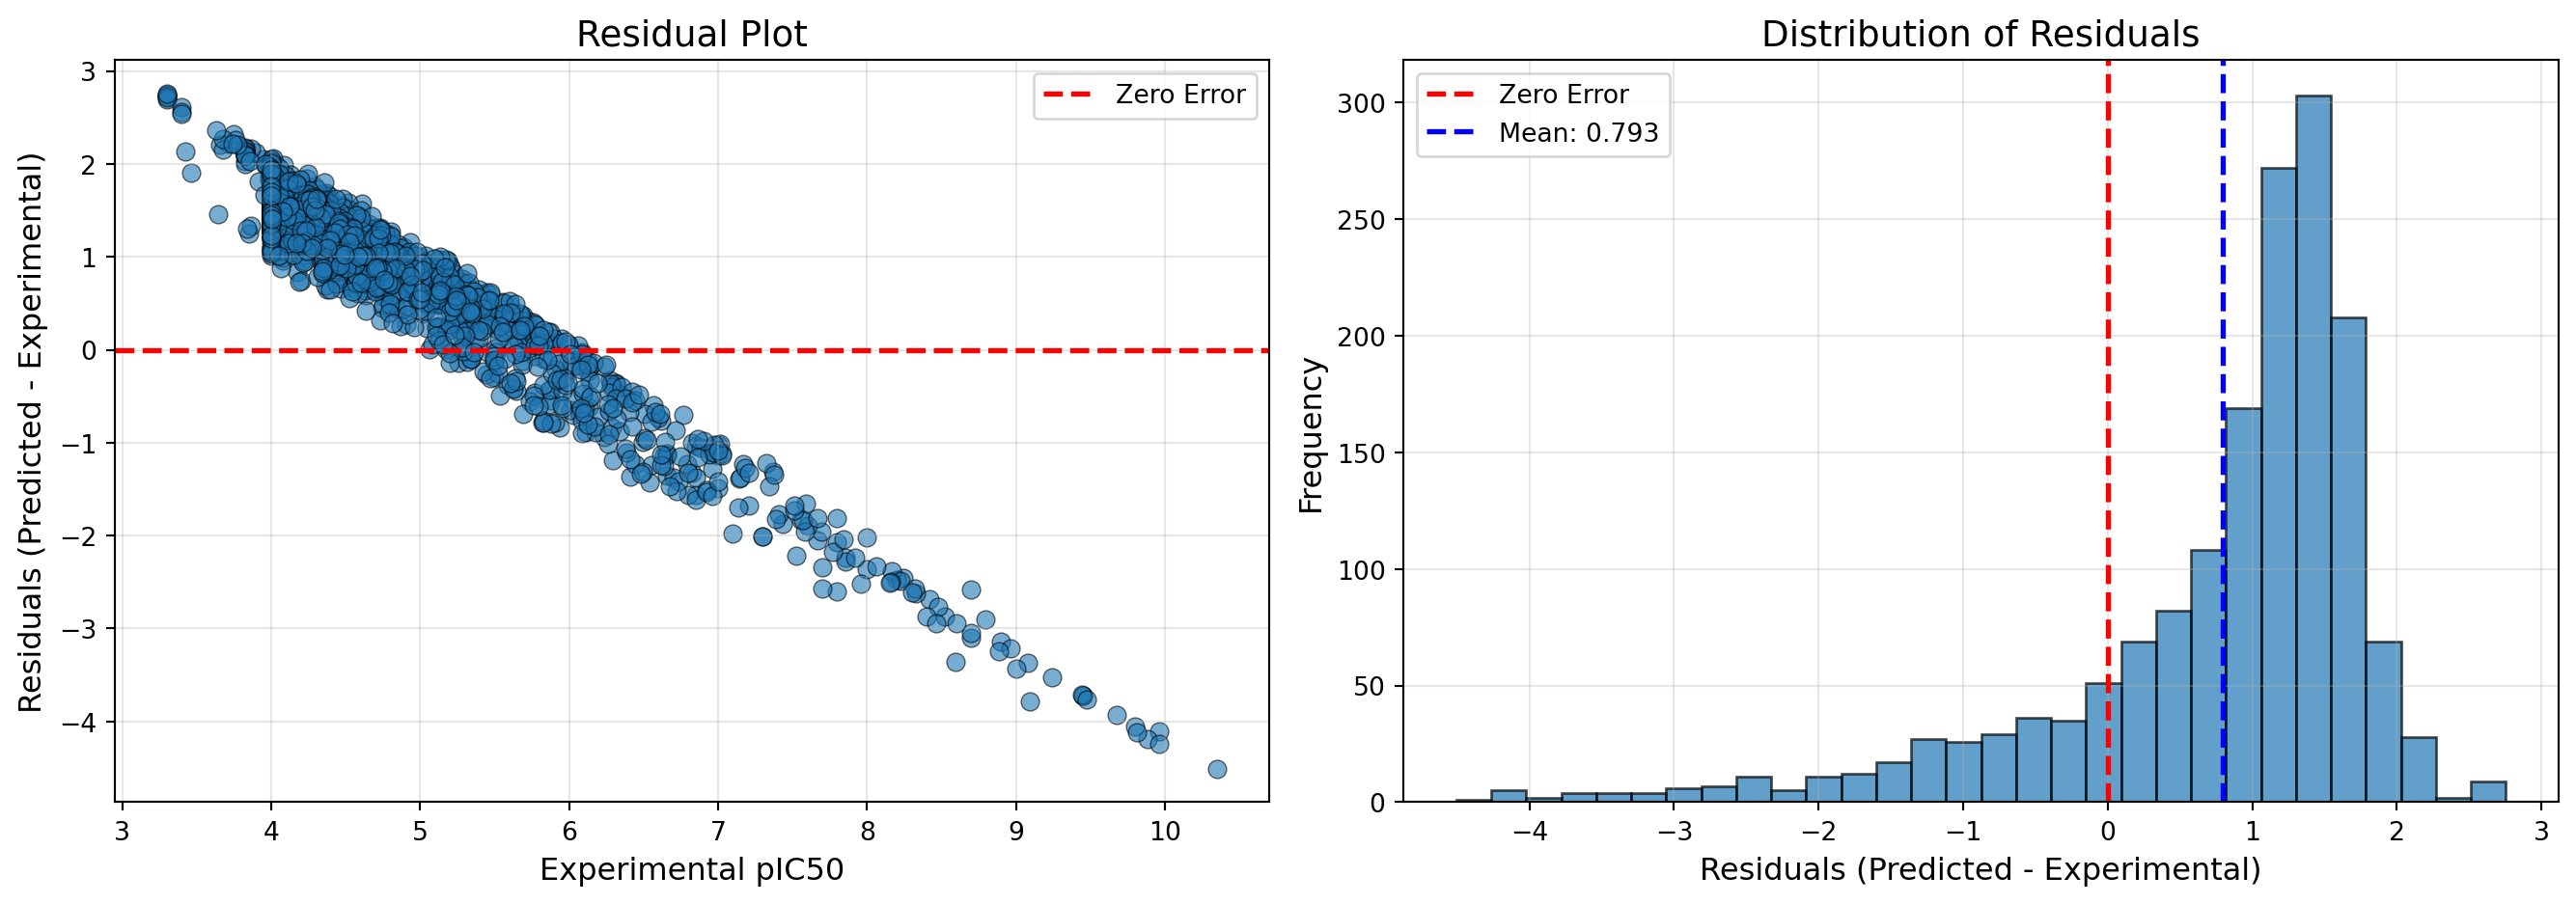

In [134]:
# Calculate residuals (difference)
SMACCAntiviralsData_predicted['residuals'] = (
    SMACCAntiviralsData_predicted['pPotency_prediction'] - 
    SMACCAntiviralsData_predicted['pIC50_experimental']
)

# Print statistics
print(f"Mean Residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f}")
print(f"Std Dev of Residuals: {SMACCAntiviralsData_predicted['residuals'].std():.3f}")
print(f"Min Residual: {SMACCAntiviralsData_predicted['residuals'].min():.3f}")
print(f"Max Residual: {SMACCAntiviralsData_predicted['residuals'].max():.3f}")

# Create residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Experimental values
axes[0].scatter(SMACCAntiviralsData_predicted['pIC50_experimental'], 
                SMACCAntiviralsData_predicted['residuals'], 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of residuals
axes[1].hist(SMACCAntiviralsData_predicted['residuals'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=SMACCAntiviralsData_predicted['residuals'].mean(), 
                color='blue', linestyle='--', linewidth=2, 
                label=f'Mean: {SMACCAntiviralsData_predicted["residuals"].mean():.3f}')
axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Residual Plot Analysis

In [135]:
print(f"Mean residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f} (Close to 0 indicates no systematic bias)")
print(f"Std deviation: {SMACCAntiviralsData_predicted['residuals'].std():.3f} (typical prediction error)")
print(f"95% of predictions are within ±{1.96 * SMACCAntiviralsData_predicted['residuals'].std():.3f} pIC50 units")

Mean residual: 0.793 (Close to 0 indicates no systematic bias)
Std deviation: 1.090 (typical prediction error)
95% of predictions are within ±2.136 pIC50 units


Let us have a look at the compounds:

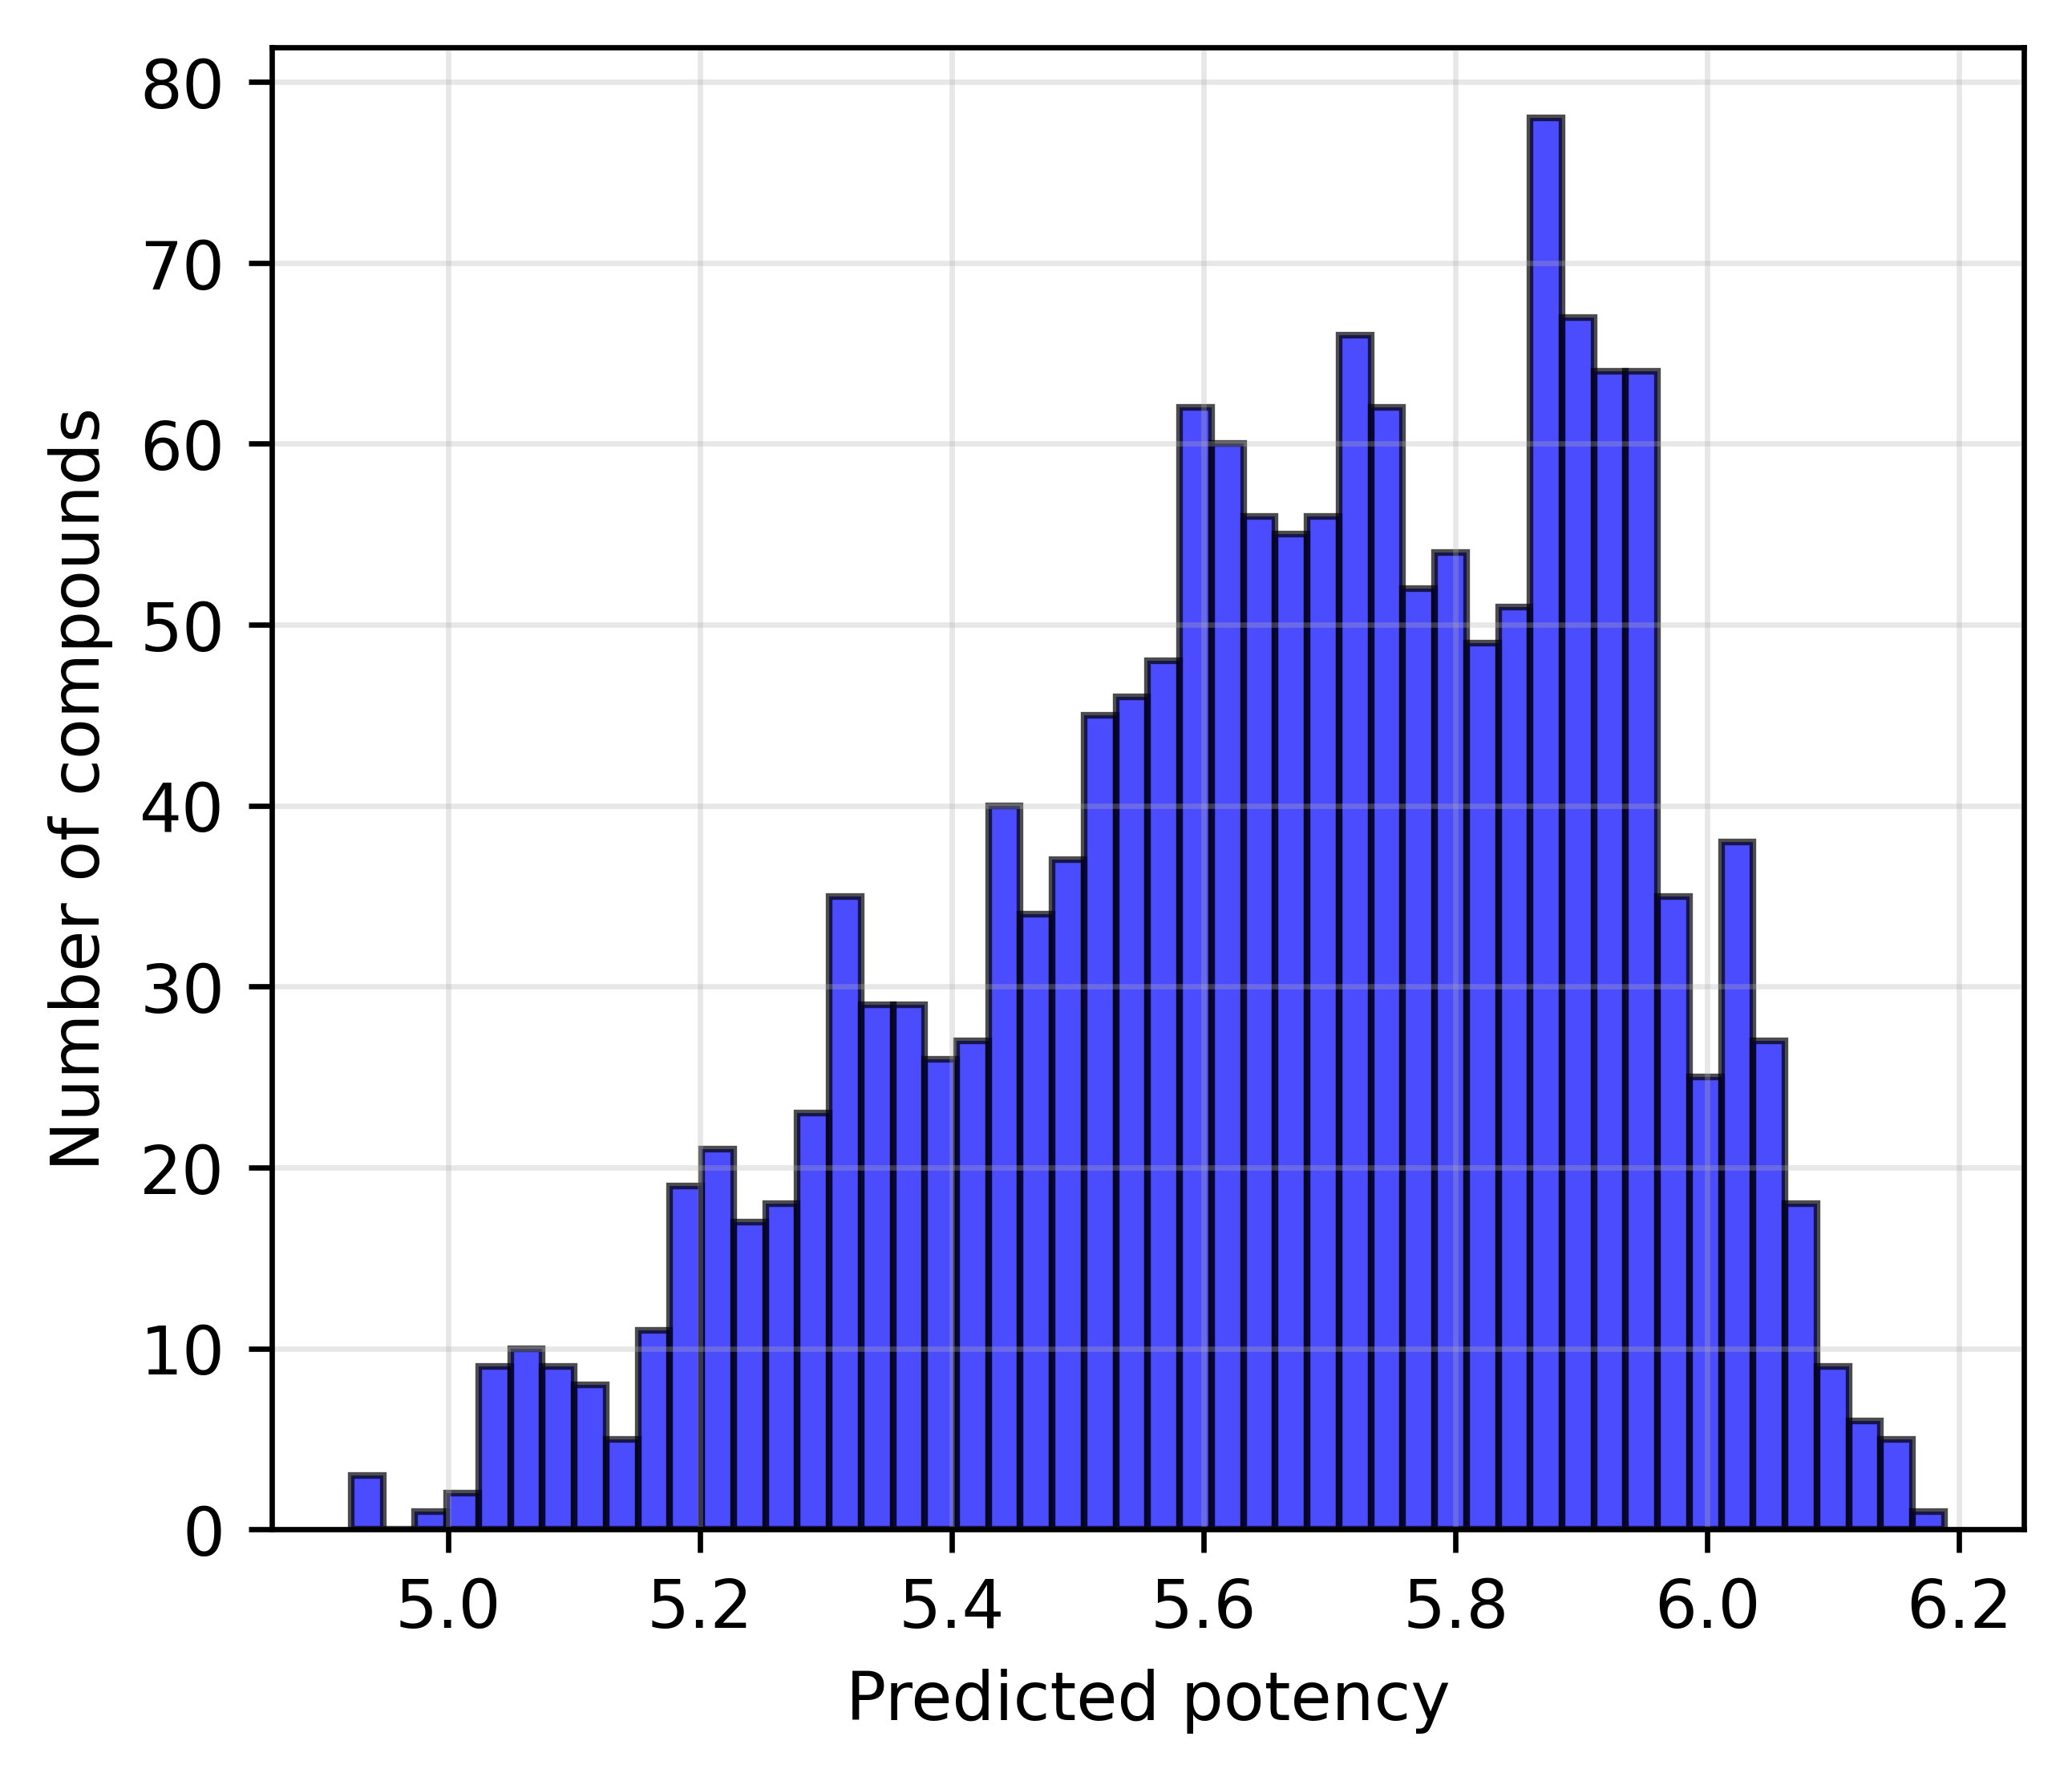

In [136]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/MarburgVirus_validation_noDuplicates_SMACCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/MarburgVirus_validation_noDuplicates_SMACCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

In [137]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 117 compounds
Low priority (5 ≤ pPotency < 6): 1491 compounds


### Top 20 compounds with higher pPotency

In [138]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.10
Highest predicted pPotency: 6.19
Range of top 20: 6.10 - 6.19


In [139]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'


SMACCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.096
  IC50:        8.015e-07 M  (801.49 nM)

Best Values (1st ranked compound):
  pPotency:    6.188
  IC50:        6.484e-07 M  (648.43 nM)
Range for Top 20 Compounds:
pPotency Range:  6.096 - 6.188

IC50 Range (M):  8.015e-07 - 6.484e-07


,Rank,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction,residuals,IC50 (M)
223,1,CC1CN=C(N1)c1ccc(Nc2nnc(Nc3ccc(cc3)C3=NCC(C)N3...,West_Nile,4.611,6.188,2.450e-05,6.484e-07,1.577,6.484e-07
878,2,Cc1ccc(NS(=O)(=O)c2ccc(NN=Cc3ccccc3OCC(O)=O)c(...,Dengue,4.357,6.156,4.391e-05,6.976e-07,1.799,6.976e-07
978,3,Cc1cccc(c1)N1CC(NC(=O)C(NC(=O)C(CCCCN)NC(=O)C(...,Dengue,5.169,6.143,6.776e-06,7.190e-07,0.974,7.190e-07
900,4,Cc1ccc(cc1)N1CC(NC(=O)C(NC(=O)C(CCCCN)NC(=O)C(...,Dengue,5.184,6.143,6.552e-06,7.197e-07,0.959,7.197e-07
751,5,COc1ccccc1NS(=O)(=O)c1ccc(NN=Cc2ccccc2OCC(O)=O...,Dengue,4.248,6.142,5.645e-05,7.211e-07,1.894,7.211e-07
1140,6,NCCCCC(NC(=O)C(CCCNC(N)=N)NC(=O)c1ccccc1)C(=O)...,Dengue,5.314,6.138,4.854e-06,7.274e-07,0.824,7.274e-07
1141,7,NCCCCC(NC(=O)C(CCCNC(N)=N)NC(=O)c1ccccc1)C(=O)...,Dengue,5.638,6.137,2.300e-06,7.292e-07,0.499,7.292e-07
1100,8,NC(Cc1c[nH]c2ccccc12)C(=O)NC(Cc1ccc(O)cc1)C(=O...,Dengue,5.135,6.133,7.332e-06,7.360e-07,0.998,7.360e-07
1139,9,NCCCCC(NC(=O)C(CCCNC(N)=N)NC(=O)c1ccccc1)C(=O)...,Dengue,5.602,6.130,2.500e-06,7.409e-07,0.528,7.409e-07
987,10,Cc1cnc(N2CC3(C2)CCOCC3)c(c1)C(=O)Nc1ccc(cc1)C(...,RSV,8.699,6.120,2.000e-09,7.579e-07,-2.579,7.579e-07


In [140]:
SMACCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_SMACCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Marburgvirus/MarburgVirus_predictedCompounds_noDuplicates_SMACCDataset.svg


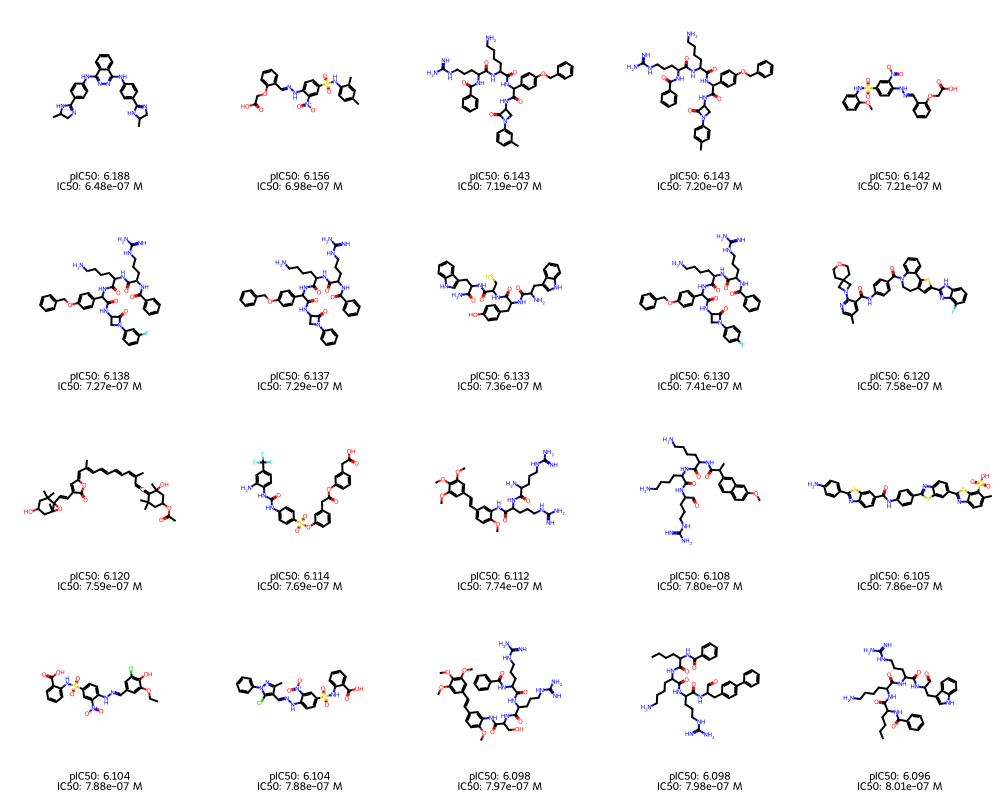

In [141]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + '/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_SMACCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'MarburgVirus_predictedCompounds_noDuplicates_SMACCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [142]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [143]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol
 Molnupiravir
  Formula: C13H19N3O7
  MW: 329.31 g/mol


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.310


In [144]:
# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to DTRA target data
DTRA_target_SMILES['Canonical_SMILES'] = DTRA_target_SMILES['SMILES'].apply(canonicalize_smiles)

# ADDED: Save original count BEFORE filtering
original_count = DTRA_target_SMILES.shape[0]

# Filter out duplicates - keep only those NOT in training set
mask = ~DTRA_target_SMILES['Canonical_SMILES'].isin(canonical_train)
DTRA_target_SMILES_filtered = DTRA_target_SMILES[mask].copy()

# Remove the helper column if you don't need it
DTRA_target_SMILES = DTRA_target_SMILES_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered DTRA target data shape for validation: {DTRA_target_SMILES.shape}")
print(f"Removed {original_count - DTRA_target_SMILES.shape[0]} duplicate compounds from DTRA target data set")  # FIXED

# Now use the filtered data
smi_lib = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib)}")

# Display the filtered data
DTRA_target_SMILES

Number of unique SMILES in training set: 152
Filtered DTRA target data shape for validation: (2, 4)
Removed 0 duplicate compounds from DTRA target data set
Total DTRA target compounds to screen: 2


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.310


Generate predictions

In [145]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [146]:
DTRA_target_SMILES_predicted = DTRA_target_SMILES.copy()
DTRA_target_SMILES_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
DTRA_target_SMILES_predicted['pPotency(M)_prediction'] = 10 ** (-DTRA_target_SMILES_predicted['pPotency_prediction'])

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
DTRA_target_SMILES_predicted.to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_DTRAtargets_predicted_all.csv"), index=False)
DTRA_target_SMILES_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "Marburgvirus/Marburgvirus_noDuplicates_DTRAtargets_predicted_all_SMILES.csv"), index=False)
DTRA_target_SMILES_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,6.146,7.139e-07
1,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,5.673,2.125e-06
